# Scramblers and the locking of metrological information — analog, digital, and the Haar limit

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

A metrological probe stores information about a parameter $\theta$ in correlations between its particles.
Notebook 34 built the best possible one: $N$ atoms twisted into a Schrodinger-cat state whose quantum Fisher
information reaches the Heisenberg value $F_Q=N^2$. Notebook 37 asked what survives when particles are *lost*.
This notebook asks a different question, and one that a laboratory faces whether or not it loses anything:

> The probe keeps evolving after it has been prepared. Atoms interact with each other, a trap is imperfect, a
> circuit runs for longer than it should. Then the phase is imprinted by the usual collective rotation
> $e^{-i\theta J_z}$ and part of the register is read out. How much information about $\theta$ does a block of
> $k$ qubits still give access to, and does the answer depend on *how* the probe was stirred?

Two different things happen. First, the total quantum Fisher information of the stirred probe for the **fixed**
generator $J_z$ collapses: notebook 35 showed that a Haar-random state has, on average, $F_Q=Nd/(d+1)\approx N$
($d=2^N$), so a cat with $F_Q=N^2$ is reduced to the standard quantum limit. The unitary-invariance identity
$F_Q[U\psi,UGU^\dagger]=F_Q[\psi,G]$ protects only the *rotated* generator $UGU^\dagger$, which no experiment with
a collective rotation implements. Second, what is left is redistributed: it moves into correlations so global that
blocks smaller than half the register retain an exponentially small share of it. This redistribution is called
**locking** here, and it is what this notebook measures, through the fraction $r_k=F_k/F_N$ of the remaining
information that $k$ qubits retain.

The fraction has a threshold at $k=N/2$, but it is not a step from $0$ to $1$. Section 4 derives the Haar
curve: below the threshold $r_k\approx k\,4^k/(2N\,2^N)$, at it $r_{N/2}\approx0.20$, above it $r_k\approx k/N$,
because a large block of a random state keeps the standard-quantum-limit value $F_k\approx k$ of its own qubits.
The sharp "all or nothing" threshold of the Hayden-Preskill type belongs to the other protocol, in which the
phase is imprinted *before* the scrambler; Section 4.3 computes that curve as well, for contrast.

Notebook 35 established the endpoint of scrambling under a global Haar unitary. This notebook is about **how the
endpoint is reached**: the dynamics of locking, two physically distinct routes to it, and the property of the
state that controls it.

### The three questions

1. **The locked curve.** We define the *locking curve* $r_k=F_k/F_N$, the quantum Fisher information retained
   by $k$ qubits of the register relative to the whole, derive its Haar average and measure it. This is the fixed
   point that every scrambler approaches.
2. **How locking is reached, in time and in depth.** Two physically different scramblers:
   an **analog** one, a chaotic spin chain evolving continuously under a non-integrable Hamiltonian, and a
   **digital** one, a brick-wall circuit built from discrete gate layers. For the digital case we compare three
   gate sets: Haar-random two-qubit gates, Clifford layers, and Clifford layers doped with $T$ gates. Clifford
   circuits are classically simulable and produce states with no *magic*, and we measure whether that shows up
   in the locking curve.
3. **What controls it.** The candidate mechanism is the **volume law**: a block locks when its reduced state is
   close to maximally mixed, that is, when its entanglement entropy is close to its number of qubits. Section 7
   turns this into a quantitative relation, $F_k\approx k\ln2\,(k-S_k)$, and tests it on every scrambler. It
   also shows that the half-chain entropy saturates before a block of three qubits has locked, and that this
   "lag" disappears when the entropy of the same block is used.

### What you will learn

*Physics*

* what locking of metrological information means, why it is a statement about subsystems rather than about
  the state as a whole, and why it must not be confused with the collapse of the total $F_Q$ for a fixed generator;
* the locking curve of a Haar-random state, derived: exponential suppression below half the register, the
  standard-quantum-limit share $F_k\approx k$ above it, and the value $r_{N/2}\approx0.20$ at the threshold;
* the difference between imprinting the phase after the scrambler (fixed generator) and before it (rotated
  generator), whose curve is the sharp Hayden-Preskill step;
* that a chain which cannot move the probe does not lock at all, however long it is evolved;
* that Clifford circuits reach the Haar locking curve **on average**, as a unitary design must, while every single
  realisation is a staircase of integer values that is zero for most small blocks: magic shows up in the
  fluctuations of $F_k$, not in its mean;
* that the locking of a block is controlled by the entropy deficit of that block, $F_k\approx k\ln2\,(k-S_k)$,
  and that comparing it with the half-chain entropy instead produces an apparent lag.

*Numerical methods*

* the symmetric-logarithmic-derivative quantum Fisher information of a reduced state, evaluated without ever
  building the reduced density matrix of the larger half, by a thin QR onto the active subspace;
* the cost argument that makes the whole locking curve $k=0,\dots,N$ cost a small multiple of its most expensive
  point;
* a leading-order Haar average with the Weingarten-free identity $\mathbb{E}[\rho_A\otimes\rho_A]$, and a
  Marchenko-Pastur integral evaluated by Gauss-Legendre quadrature;
* second-order Trotter-Suzuki evolution of a disordered, non-integrable chain, and how to choose $dt$ by
  measuring the error rather than by trusting the order;
* brick-wall circuits over three gate sets, and sampling the single-qubit Clifford group;
* averaging over disorder and circuit realisations with standard errors of the mean.

*Implementation practice*

* `lax.scan` over Trotter steps with the gate list closed over, so the step compiles once;
* `jit` over a whole circuit layer, and why the brick-wall loop must be unrolled at trace time;
* a reduced-state quantity evaluated for every $k$ in one pass, reusing one application of the generator;
* `vmap` over disorder realisations, and the discipline of splitting keys explicitly so that a figure redrawn
  tomorrow is the same figure.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys;
* [06 — states, observables and entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb):
  reduced density matrices, Schmidt values, entanglement entropy, the Page value;
* [10 — random unitaries and random circuits](../ch04_digital_quantum_circuits/10_random_unitaries_and_random_circuits.ipynb):
  the Haar measure, Mezzadri's recipe, the single-qubit Clifford group, brick-wall circuits;
* [12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) and
  [15 — quench dynamics](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb):
  Trotter-Suzuki evolution, entanglement growth, integrable versus chaotic chains;
* [29 — quantum Fisher information](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb) and
  [30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb):
  $F_Q=4\,\mathrm{Var}(G)$ for pure states, the symmetric logarithmic derivative for mixed ones;
* [35 — scrambling a metrological probe](../ch10_quantum_metrology_protocols/35_oat_plus_haar_scrambling.ipynb):
  the unitary-invariance identity and the endpoint of scrambling under a global Haar unitary. Section 3 recalls
  everything this notebook needs from it.

**What comes next.** [39 — QFI spreading in spin chains](../ch10_quantum_metrology_protocols/39_qfi_spreading_in_spin_chains.ipynb)
follows the metrological resource through quenched transverse-field Ising and XXZ chains and measures the light
cone of the block-resolved quantum Fisher information after a local encoding.

**Conventions.** Qubit $q$ = tensor axis $q$, $0$-indexed; $\vert0\rangle$ is the $+1$ eigenstate of $Z$.
Collective spin operators are $J_a=\tfrac12\sum_q\sigma^a_q$, so the standard quantum limit is $F_Q=N$ and the
Heisenberg limit $F_Q=N^2$. The parameter is imprinted on the **whole** register by $U(\theta)=e^{-i\theta J_z}$
**after** the scrambler, unless stated otherwise (Section 4.3 is the one exception), and only then is a subsystem
selected. "Keeping $k$ qubits" always means keeping the **last** $k$ tensor axes, $q=N-k,\dots,N-1$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we take the state constructors, `apply_gate` and `apply_gates` (the einsum that applies a small
matrix to chosen axes, and a circuit as a list of them), `apply_collective` for the matrix-free $\sum_qP_q$,
`qfi_pure`, `tebd_gates` for the Trotter step, `haar_unitary`, `single_qubit_cliffords`, and the entropy
routines; `rdm`, `collective_dense` and the dense SLD formula `qfi_mixed` serve only as an independent reference
in the first checkpoint. Everything specific to locking is built below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


from functools import lru_cache          # used to cache one compiled program per subsystem size


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(f, *args, budget=0.3, min_reps=3, max_reps=200):
    """Return (result, compile_time, best_run_time); JAX is asynchronous, so every value is blocked on."""
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best


def half_entropy(psi):
    """Entanglement entropy in BITS of the first half of the register against the second.

    The engine's `entanglement_entropy` already uses base 2, so no conversion is needed here.
    """
    return float(entanglement_entropy(psi, range(psi.ndim // 2)))


def page_entropy_bits(n_a, n_b):
    """Page's average entropy of a random pure state, in bits, for a d_A x d_B bipartition.

    MATH   <S> = sum_{j=d_B+1}^{d_A d_B} 1/j  -  (d_A - 1)/(2 d_B)     (natural log), d_A <= d_B.
    """
    d_a, d_b = 2 ** min(n_a, n_b), 2 ** max(n_a, n_b)
    s = float(np.sum(1.0 / np.arange(d_b + 1, d_a * d_b + 1)) - (d_a - 1) / (2.0 * d_b))
    return s / np.log(2.0)

## 3. The locking curve

### 3.1 The quantity

The protocol is the one of notebook 30, stopped one step early. A probe $\vert\psi\rangle$ of $N$ qubits is
prepared; the parameter is imprinted on **all** of them,

$$\vert\psi_\theta\rangle=e^{-i\theta J_z}\vert\psi\rangle,\qquad J_z=\tfrac12\sum_{q=0}^{N-1}Z_q;$$

and then only $k$ qubits are kept, the other $N-k$ being traced out — not lost, merely not measured. The state
available to the experimenter is the reduced density matrix

$$\rho_k(\theta)=\mathrm{Tr}_{\text{first } N-k}\left[\vert\psi_\theta\rangle\langle\psi_\theta\vert\right],$$

which is mixed, so the quantum Fisher information it carries is given by the symmetric-logarithmic-derivative
formula of notebook 30,

$$F_k=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left\vert\langle m\vert\partial_\theta\rho_k\vert n\rangle\right\vert^2}{\lambda_m+\lambda_n},
\qquad \rho_k=\sum_m\lambda_m\vert m\rangle\langle m\vert. \tag{1}$$

The **locking curve** is the profile

$$r_k=\frac{F_k}{F_N},\qquad k=0,1,\dots,N, \tag{2}$$

the fraction of the total phase information that $k$ qubits retain. It starts at $r_0=0$ (no qubits, no
information) and ends at $r_N=1$ by construction. Everything interesting is in the shape in between.

> **Physics insight.** $r_k$ is *not* a measure of entanglement, and it is not a property of $\vert\psi\rangle$
> alone: it depends on the generator. Section 4.3 evaluates the same Haar-random states with the fixed generator
> $J_z$ and with a scrambled one, and the two locking curves differ qualitatively. What $r_k$ measures is the
> *accessibility* of one specific piece of physical information from one specific part of the register.

### 3.2 Computing it without building the large reduced state

Write the state tensor as a matrix whose **rows** are labelled by the $k$ kept axes and whose **columns** are
labelled by the $N-k$ traced axes, $\Psi\in\mathbb{C}^{2^{k}\times2^{N-k}}$. Tracing out the column index is
then a matrix product, $\rho_k=\Psi\Psi^\dagger$. Differentiating
$\vert\psi_\theta\rangle=e^{-i\theta J_z}\vert\psi\rangle$ at $\theta=0$ gives
$\partial_\theta\vert\psi_\theta\rangle=-iJ_z\vert\psi\rangle$, so with $\Phi$ the matrix reshaped the same way
from $J_z\vert\psi\rangle$,

$$\partial_\theta\rho_k=-i\left(T-T^\dagger\right),\qquad T=\Phi\Psi^\dagger. \tag{3}$$

Eq. (3) is worth one line of algebra: $\rho_k(\theta)$ is built from $e^{-i\theta J_z}\vert\psi\rangle$, whose
$\theta$-derivative at the origin is $-iJ_z\vert\psi\rangle$; the product rule on $\Psi\Psi^\dagger$ gives
$(-i\Phi)\Psi^\dagger+\Psi(-i\Phi)^\dagger=-i(T-T^\dagger)$.

One more line shows which part of the generator matters. Split $J_z=J_A+J_B$ into the collective spins of the
kept block $A$ and the traced block $B$. The term $J_B$ contributes $-i\,\mathrm{Tr}_B[J_B,\vert\psi\rangle\langle\psi\vert]$,
a partial trace of a commutator with an operator acting on $B$ only, which vanishes by cyclicity of the trace
over $B$. Hence

$$\partial_\theta\rho_k=-i\left[J_A,\rho_k\right],\qquad F_k=F_Q\left[\rho_k,J_A\right], \tag{3a}$$

the quantum Fisher information of the reduced state for the collective spin of the kept qubits alone. The
traced qubits influence $F_k$ only through how mixed they leave $\rho_k$. The checkpoint below uses Eq. (3a) as
an independent test of the matrix-free route.

Two facts make Eq. (1) cheap. First, $\rho_k$ has rank at most $2^{\min(k,N-k)}$, so for $k>N/2$ it is a large
matrix with a small support. Second, $\Psi$ and $\Phi$ have only $2^{N-k}$ columns each: a thin QR
factorisation of the $2^{k}\times2^{N-k+1}$ matrix $[\Psi\;\Phi]$ produces an isometry $Q$ onto a subspace of
dimension at most $2^{N-k+1}$ that contains the whole column space of $\Psi$ *and* of $\Phi$, hence the whole
support of $\rho_k$ and of $\partial_\theta\rho_k$. Replacing $\Psi\to Q^\dagger\Psi$ and $\Phi\to Q^\dagger\Phi$
changes no non-zero eigenvalue and no matrix element that Eq. (1) uses. The cost of the point $k$ therefore scales as
$8^{\min(k,\,N-k)}$, and the whole curve costs no more than a small multiple of its midpoint.

> **Numerical practice.** The sum in Eq. (1) runs only over pairs with $\lambda_m+\lambda_n>0$. Numerically the
> zero eigenvalues of a rank-deficient $\rho_k$ come out as $\pm10^{-17}$, and dividing by them produces enormous
> garbage. The guard is a tolerance, and it must be applied *inside* the expression with `jnp.where` on both
> branches — the standard JAX idiom for "compute this only where it is defined", because a `where` that still
> evaluates the bad branch will produce a `nan` that propagates through `grad`.

In [4]:
# ==============================================================================
# STEP 1: the SLD quantum Fisher information of a reduced state, QR-compressed
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """SLD quantum Fisher information from a state and its derivative -- Eq. (1).

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n)  over lam_m + lam_n > tol,
           where rho = sum_m lam_m |m><m|.
    IMPL   the double `jnp.where` guards the division: the second one replaces the denominator by 1
           wherever the pair is excluded, so no inf/nan is ever formed, not even in an unused branch.
    COST   one Hermitian eigendecomposition of rho, O(dim^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def subsystem_qfi(psi, phi, k, tol=1e-12):
    """QFI retained by the LAST k qubits after the phase was imprinted on all N -- Eqs. (1) and (3).

    ARGS   psi : state tensor (2,)*N;  phi : the tensor J|psi> for the generator J used to imprint;
           k   : number of kept qubits (the last k axes).
    MATH   Psi = psi reshaped to (2^{N-k}, 2^k), rho_k = Psi^dag Psi,
           d rho_k / d theta = -i (T - T^dag) with T = Phi^dag Psi.
    IMPL   when 2^k > 2^{N-k} a thin QR of [Psi^dag | Phi^dag] gives an isometry onto the (at most
           2^{N-k+1})-dimensional active subspace; the non-zero spectrum and every matrix element
           entering Eq. (1) are unchanged by the projection.
    COST   O(8^min(k, N-k)).  phi is passed in so that ONE application of J serves the whole curve.
    """
    if k == 0:
        return 0.0
    Psi = psi.reshape(-1, 2 ** k).T                # rows = kept block, columns = traced block
    Phi = phi.reshape(-1, 2 ** k).T
    if Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    Tm = Phi @ Psi.conj().T
    return float(qfi_from_derivative(Psi @ Psi.conj().T, -1j * (Tm - Tm.conj().T), tol))


@lru_cache(maxsize=None)
def _qfi_at_k(k, tol=1e-12):
    """A jitted `subsystem_qfi` specialised to one k.

    JAX    k fixes every array SHAPE in the routine, so it must be a compile-time constant, not an
           argument. Caching one compiled program per k means the whole locking curve is compiled
           N times in total and then reused for every state the notebook ever evaluates -- a few
           hundred calls. Without this the QR and the eigendecomposition are dispatched op by op.
    """
    return jax.jit(lambda psi, phi: _subsystem_qfi_traced(psi, phi, k, tol))


def _subsystem_qfi_traced(psi, phi, k, tol):
    """The body of `subsystem_qfi`, returning a traced array instead of a Python float."""
    Psi = psi.reshape(-1, 2 ** k).T
    Phi = phi.reshape(-1, 2 ** k).T
    if Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    Tm = Phi @ Psi.conj().T
    return qfi_from_derivative(Psi @ Psi.conj().T, -1j * (Tm - Tm.conj().T), tol)


def locking_curve(psi, P=None):
    """The whole profile F_k, k = 0..N, for the generator J = (1/2) sum_q P_q  (default P = Z).

    One application of the collective generator is reused for every k -- that, and the per-k
    compilation above, are the two reasons the curve is affordable: the N+1 points then cost one
    eigendecomposition each, the largest of dimension 2^ceil(N/2).
    """
    P = Z if P is None else P
    phi = 0.5 * apply_collective(psi, P)
    return np.array([0.0] + [float(_qfi_at_k(k)(psi, phi)) for k in range(1, psi.ndim + 1)])

Before using Eq. (1) on anything interesting we check it against the two cases whose answer is known in closed
form. At $k=N$ nothing is traced out, the state is pure, and the symmetric-logarithmic-derivative formula must
collapse to the variance formula $F_N=4\,\mathrm{Var}(J_z)$ of notebook 29. Two states pin the scale: the
coherent spin state $\vert+\rangle^{\otimes N}$, for which $F_N=N$ (the standard quantum limit), and the GHZ
state, for which $F_N=N^2$ (the Heisenberg limit). For $k<N$ two further checks follow: the QR compression must
change nothing, and Eq. (3a) must agree with a completely independent dense computation (the engine's `rdm`, a
dense $J_A$ and the engine's `qfi_mixed`). A generator placed on the wrong qubits must fail the second check.

In [5]:
# ==============================================================================
# CHECKPOINT: k = N reproduces 4 Var(J_z); the two limits come out at N and N^2
# ==============================================================================
N = 12                                   # main system size of this notebook

psi_plus = product_state("+" * N)
psi_ghz = ghz_state(N)

for name, psi, expected in (("coherent |+>^N", psi_plus, float(N)),
                            ("GHZ", psi_ghz, float(N ** 2))):
    phi = 0.5 * apply_collective(psi, Z)
    f_sld = subsystem_qfi(psi, phi, N)
    f_var = float(qfi_pure(psi, Z))       # engine: <G^2> - <G>^2 with G = 2 J_z, i.e. 4 Var(J_z)
    print(f"{name:16s}  F_N (SLD) = {f_sld:10.6f}   4 Var(J_z) = {f_var:10.6f}   "
          f"expected = {expected:8.2f}   err = {abs(f_sld - f_var):.2e}")
    assert abs(f_sld - f_var) < 1e6 * TOL
    assert abs(f_sld - expected) < 1e6 * TOL

# --- CHECKPOINT: the QR compression is exact, not an approximation --------------------
key = jax.random.PRNGKey(20260920)
key, sk = jax.random.split(key)
psi_rand = haar_state(sk, N)
phi_rand = 0.5 * apply_collective(psi_rand, Z)
# The uncompressed reference needs a dense 2^k x 2^k eigendecomposition -- 4096 x 4096 at k = N = 12, over a
# minute on one CPU core -- so this check uses a 10-qubit state, where the largest one is 1024 x 1024.
N_CHK = 10
key, sk = jax.random.split(key)
psi_chk = haar_state(sk, N_CHK)
phi_chk = 0.5 * apply_collective(psi_chk, Z)
err_compress = 0.0
for k in range(1, N_CHK + 1):
    Psi = psi_chk.reshape(-1, 2 ** k).T
    Phi = phi_chk.reshape(-1, 2 ** k).T
    Tm = Phi @ Psi.conj().T               # uncompressed: full 2^k x 2^k matrices
    f_full = float(qfi_from_derivative(Psi @ Psi.conj().T, -1j * (Tm - Tm.conj().T)))
    err_compress = max(err_compress, abs(f_full - subsystem_qfi(psi_chk, phi_chk, k)))
print(f"\ncompressed vs uncompressed, N = {N_CHK}, all k = 1..{N_CHK}: max err = {err_compress:.2e}")
assert err_compress < 1e6 * TOL

# --- CHECKPOINT: Eq. (3a), independently -- dense rho_A from the engine, dense J_A, dense SLD formula ----
# The two routes share nothing but the state: `rdm` + `collective_dense` + `qfi_mixed` versus Psi/Phi + Eq. (3).
# Wrong control: the collective spin of the FIRST k qubits instead of the kept (last) ones must disagree.
err_dense, gap_wrong = 0.0, np.inf
for k in range(1, 7):
    rho_A = rdm(psi_rand, range(N - k, N))
    f_dense = float(qfi_mixed(rho_A, collective_dense(Z, k)))
    f_mf = subsystem_qfi(psi_rand, phi_rand, k)
    phi_wrong = 0.5 * apply_collective(psi_rand, Z, qubits=range(k))
    gap_wrong = min(gap_wrong, abs(subsystem_qfi(psi_rand, phi_wrong, k) - f_dense) / f_dense)
    err_dense = max(err_dense, abs(f_dense - f_mf))
print(f"Eq. (3a): dense F_Q[rho_A, J_A] vs matrix-free F_k, k = 1..6: max err = {err_dense:.2e}")
print(f"wrong control (generator on the first k qubits): smallest relative deviation = {gap_wrong:.2f}")
assert err_dense < 1e6 * TOL
assert gap_wrong > 0.1

coherent |+>^N    F_N (SLD) =  12.000000   4 Var(J_z) =  12.000000   expected =    12.00   err = 2.13e-14
GHZ               F_N (SLD) = 144.000000   4 Var(J_z) = 144.000000   expected =   144.00   err = 5.68e-14



compressed vs uncompressed, N = 10, all k = 1..10: max err = 8.88e-15


Eq. (3a): dense F_Q[rho_A, J_A] vs matrix-free F_k, k = 1..6: max err = 8.88e-16
wrong control (generator on the first k qubits): smallest relative deviation = 1.00


## 4. The locked curve: what a Haar-random state retains

Every scrambler in this notebook is trying, in its own way, to turn the probe into a generic state. So the first
thing to measure is the target: the locking curve of a Haar-random state.

The expected shape follows from one fact established in notebook 10 and used again in notebook 35. For a
Haar-random $\vert\psi\rangle$ and $k<N/2$, the reduced state of $k$ qubits is exponentially close to maximally
mixed,

$$\mathbb{E}\left\Vert\rho_k-\frac{\mathbb{1}}{2^k}\right\Vert_1\lesssim\sqrt{\frac{2^{k}}{2^{N-k}}},$$

and the maximally mixed state is a fixed point of *every* unitary: $e^{-i\theta J_z}\,\mathbb{1}\,e^{i\theta J_z}=\mathbb{1}$.
A state that does not move when the parameter changes carries no information about it, so $F_k\to0$. The
suppression is governed by $2^{k}/2^{N-k}=4^{k}/2^{N}$, which crosses unity at $k=N/2$. The next subsection
turns this into formulas for both sides of the threshold.

### 4.1 The closed-form Haar locking curve

Write $d_A=2^k$, $d_B=2^{N-k}$, $d=d_Ad_B$ and $\rho_k=\mathbb{1}/d_A+\delta$.

*Small blocks, $k<N/2$.* All eigenvalues of $\rho_k$ are close to $1/d_A$, so in Eq. (1) we may replace
$\lambda_m+\lambda_n$ by $2/d_A$. With Eq. (3a), $\langle m\vert\partial_\theta\rho_k\vert n\rangle=-i(\lambda_n-\lambda_m)\langle m\vert J_A\vert n\rangle$, and

$$F_k\approx d_A\sum_{m,n}(\lambda_m-\lambda_n)^2\left\vert\langle m\vert J_A\vert n\rangle\right\vert^2
=2d_A\left[\mathrm{Tr}\left(\rho_k^2J_A^2\right)-\mathrm{Tr}\left(\rho_kJ_A\rho_kJ_A\right)\right].$$

The bracket is quadratic in the state, so its Haar average needs only the second moment. For a Haar-random state,
$\mathbb{E}\left[\vert\psi\rangle\langle\psi\vert^{\otimes2}\right]=(\mathbb{1}+\mathcal{S})/(d(d+1))$ with $\mathcal{S}$ the swap of the two copies;
tracing out both copies of $B$ gives

$$\mathbb{E}\left[\rho_k\otimes\rho_k\right]=\frac{d_B^2\,\mathbb{1}+d_B\,\mathcal{S}_A}{d(d+1)},$$

and with $\mathrm{Tr}[(X\rho\otimes Y\rho)\mathcal{S}_A]=\mathrm{Tr}(X\rho Y\rho)$ one finds
$\mathbb{E}\,\mathrm{Tr}(\rho_kX\rho_kY)=\left[d_B^2\,\mathrm{Tr}(XY)+d_B\,\mathrm{Tr}X\,\mathrm{Tr}Y\right]/(d(d+1))$. Taking
$(X,Y)=(\mathbb{1},J_A^2)$ and $(J_A,J_A)$, and using $\mathrm{Tr}J_A=0$ and $\mathrm{Tr}J_A^2=kd_A/4$,

$$\mathbb{E}\,F_k\approx2d_A\,\frac{d_Ad_B\,\mathrm{Tr}J_A^2}{d(d+1)}\approx\frac{k}{2}\,\frac{d_A}{d_B},
\qquad r_k\approx\frac{k\,4^k}{2N\,2^N}\qquad(k<N/2), \tag{5}$$

where the last step divides by the Haar average $F_N=Nd/(d+1)\approx N$ of notebook 35. The ratio of
consecutive points is $r_{k+1}/r_k=4(k+1)/k$: $8$, $6$, $5.3$, $5$, … rather than a constant factor of four.

*Large blocks, $k>N/2$.* Now $B$ is small and $\rho_k$ has rank $d_B<d_A$. Convexity of the quantum Fisher
information (notebook 30) applied to the eigen-decomposition of $\rho_k$, together with the fact that the average
of the variances of the components is at most the variance of the mixture, gives
$F_k\le4\,\mathrm{Var}_{\rho_k}(J_A)=4\,\mathrm{Var}_{\psi}(J_A)$, whose Haar average is
$kd/(d+1)\approx k$ by the same calculation as $F_N$. The numbers below show that the bound is nearly saturated
a few qubits past the threshold, so

$$F_k\approx k,\qquad r_k\approx\frac{k}{N}\qquad(k\ \text{well above}\ N/2). \tag{6}$$

A large block keeps the standard-quantum-limit value of its own qubits, and no more: the total $F_N\approx N$
of a random state is itself only the standard quantum limit.

*The threshold, $k=N/2$.* Now $d_A=d_B$ and the eigenvalues $x=d_A\lambda$ are spread over $[0,4]$ by the
Marchenko-Pastur law with density $p(x)=\sqrt{(4-x)/x}/(2\pi)$ (notebook 37, Section 12; quoted there without proof). Treating the matrix elements of $J_A$
in the eigenbasis of $\rho_k$ as random, $\vert\langle m\vert J_A\vert n\rangle\vert^2\approx\mathrm{Tr}J_A^2/d_A^2$, Eq. (1) becomes

$$r_{N/2}\approx\frac14\,\mathbb{E}_{x,y\sim p}\left[\frac{(x-y)^2}{x+y}\right]\approx0.198, \tag{7}$$

independent of $N$; the code evaluates the double integral by Gauss-Legendre quadrature after the substitution
$x=4\sin^2u$, which turns $p(x)\,dx$ into $(4/\pi)\cos^2u\,du$.

In the limit $N\to\infty$ at fixed fraction $k/N$ the curve therefore tends to $0$ below one half and to $k/N$
above it: a jump of height $1/2$ at the threshold, not a step to $1$.

### 4.2 Measurement

For four system sizes we draw Haar-random states, evaluate the locking curve of each, and average with the
standard error of the mean. The raw $F_k$ are kept as well, because Eq. (6) is a statement about $F_k$ itself.

In [6]:
# ==============================================================================
# STEP 2: the Haar-random reference curve for several N
# ==============================================================================
N_HAAR = [6, 8, 10, 12]          # system sizes for the reference curve
R_HAAR = 48                      # Haar realisations per size

haar_mean, haar_sem, haar_F = {}, {}, {}
t0 = time.time()
for n in N_HAAR:
    rows = []
    for r in range(R_HAAR):
        key, sk = jax.random.split(key)
        rows.append(locking_curve(haar_state(sk, n)))
    rows = np.array(rows)
    haar_F[n] = rows                                  # raw F_k, one row per state
    ratios = rows / rows[:, -1:]                      # normalise EACH realisation before averaging
    haar_mean[n] = ratios.mean(0)
    haar_sem[n] = ratios.std(0, ddof=1) / np.sqrt(R_HAAR)
print(f"Haar reference curves for N = {N_HAAR}, {R_HAAR} realisations each, in {time.time() - t0:.1f} s\n")

print(f"  r_k = F_k / F_N   (mean over {R_HAAR} Haar-random states, standard error in brackets)")
print(f"  {'k':>3} | " + " ".join(f"{'N=' + str(n):>17s}" for n in N_HAAR))
for k in range(max(N_HAAR) + 1):
    row = f"  {k:>3} | "
    for n in N_HAAR:
        row += f"{haar_mean[n][k]:9.5f} ({haar_sem[n][k]:5.0e}) " if k <= n else " " * 18
    print(row)

Haar reference curves for N = [6, 8, 10, 12], 48 realisations each, in 6.8 s

  r_k = F_k / F_N   (mean over 48 Haar-random states, standard error in brackets)
    k |               N=6               N=8              N=10              N=12
    0 |   0.00000 (0e+00)   0.00000 (0e+00)   0.00000 (0e+00)   0.00000 (0e+00) 
    1 |   0.00538 (7e-04)   0.00090 (1e-04)   0.00019 (2e-05)   0.00004 (6e-06) 
    2 |   0.04277 (3e-03)   0.00808 (6e-04)   0.00130 (8e-05)   0.00036 (3e-05) 
    3 |   0.19556 (7e-03)   0.04501 (2e-03)   0.00905 (4e-04)   0.00194 (8e-05) 
    4 |   0.53584 (1e-02)   0.19964 (3e-03)   0.04718 (1e-03)   0.01024 (2e-04) 
    5 |   0.80242 (1e-02)   0.49240 (5e-03)   0.19971 (2e-03)   0.04938 (5e-04) 
    6 |   1.00000 (0e+00)   0.71093 (6e-03)   0.47153 (3e-03)   0.19686 (1e-03) 
    7 |                     0.86645 (6e-03)   0.66068 (3e-03)   0.45501 (2e-03) 
    8 |                     1.00000 (0e+00)   0.79047 (3e-03)   0.62649 (2e-03) 
    9 |                        

The curves are **not** symmetric: at the midpoint $k=N/2$ the retained fraction is about $0.2$ for every $N$,
not $0.5$. Half of the register is worth a fifth of the information. Below the midpoint the values fall faster
than a factor of four per qubit removed, and above it they approach the straight line $k/N$. The next cell
compares the table with Eqs. (5)–(7), and with two wrong laws that a quick reading of the table could suggest.

In [7]:
# ==============================================================================
# CHECKPOINT: Eqs. (5), (6), (7) against the measured Haar curves
# ==============================================================================
def mp_midpoint(n_nodes=200):
    """Eq. (7):  (1/4) E[(x-y)^2/(x+y)] for x, y independent Marchenko-Pastur(1) variables.

    MATH   x = 4 sin^2 u maps p(x) dx = sqrt((4-x)/x)/(2 pi) dx  onto  (4/pi) cos^2 u du,  u in [0, pi/2];
           the integrand is then smooth and Gauss-Legendre converges fast.
    """
    g, w = np.polynomial.legendre.leggauss(n_nodes)
    u = (g + 1) * np.pi / 4
    w = w * np.pi / 4 * (4 / np.pi) * np.cos(u) ** 2          # quadrature weights times the density
    x = 4 * np.sin(u) ** 2
    num = (x[:, None] - x[None, :]) ** 2 / (x[:, None] + x[None, :])
    return 0.25 * float(w @ num @ w), float(w.sum())


R_MID, w_norm = mp_midpoint()
print(f"Eq. (7): r_(N/2) -> {R_MID:.4f}   (quadrature weights sum to {w_norm:.12f})\n")
assert abs(w_norm - 1) < 1e-10

print(f"  {'N':>3} {'r_(N/2)':>9} {'sem':>7} | {'r_(N/2-2) / Eq.(5)':>19} | {'r_(N/2-1)/r_(N/2-3)':>20} {'Eq.(5)':>7} "
      f"{'x16':>5} | {'max_k |F_k/k - 1|, k>=N/2+3':>28}")
for n in N_HAAR:
    h = n // 2
    law5 = lambda k: k * 4.0 ** k / (2 * n * 2.0 ** n)
    z_mid = (haar_mean[n][h] - R_MID) / haar_sem[n][h]
    line = f"  {n:>3} {haar_mean[n][h]:9.4f} {haar_sem[n][h]:7.4f} | "
    if h - 3 >= 1:
        ratio5 = haar_mean[n][h - 2] / law5(h - 2)
        slope = haar_mean[n][h - 1] / haar_mean[n][h - 3]          # Eq. (5): 16 (h-1)/(h-3); constant x4/qubit: 16
        line += f"{ratio5:19.3f} | {slope:20.1f} {16 * (h - 1) / (h - 3):7.1f} {16:5d} | "
    else:
        line += f"{'':19s} | {'':20s} {'':7s} {'':5s} | "
    big = [k for k in range(h + 3, n)]
    dev = max(abs(haar_F[n][:, k].mean() / k - 1) for k in big) if big else np.nan
    print(line + f"{dev:28.3f}")
    assert abs(z_mid) < 4                                                      # Eq. (7)
    if n >= 8:
        assert abs(haar_mean[n][h] - 0.25) > 8 * haar_sem[n][h]               # wrong control: Eq. (5) at k = N/2
    if n >= 10:
        assert abs(ratio5 - 1) < 0.15                                          # Eq. (5), two qubits below the threshold
        assert abs(np.log(slope / (16 * (h - 1) / (h - 3)))) < abs(np.log(slope / 16))   # k 4^k beats 4^k
        assert dev < 0.04                                                      # Eq. (6)
        assert haar_mean[n][n - 1] < 0.95                                      # wrong control: a step to r = 1
print("\nEq. (7) holds at every N, Eq. (5) two qubits below the threshold, Eq. (6) three qubits above it.")

# Common pitfall, measured: mean of ratios versus ratio of means
n = N_HAAR[-1]
ratio_of_means = haar_F[n].mean(0) / haar_F[n][:, -1].mean()
diff_pitfall = np.max(np.abs(haar_mean[n] - ratio_of_means)[1:-1] / haar_sem[n][1:-1])
print(f"N = {n}: |mean of ratios - ratio of means| <= {diff_pitfall:.2f} standard errors over k = 1..{n - 1}")

Eq. (7): r_(N/2) -> 0.1977   (quadrature weights sum to 1.000000000000)

    N   r_(N/2)     sem |  r_(N/2-2) / Eq.(5) |  r_(N/2-1)/r_(N/2-3)  Eq.(5)   x16 |  max_k |F_k/k - 1|, k>=N/2+3
    6    0.1956  0.0066 |                     |                                    |                          nan
    8    0.1996  0.0030 |               1.034 |                 49.7    48.0    16 |                        0.016
   10    0.1997  0.0019 |               0.965 |                 36.4    32.0    16 |                        0.017
   12    0.1969  0.0010 |               0.983 |                 25.5    26.7    16 |                        0.018

Eq. (7) holds at every N, Eq. (5) two qubits below the threshold, Eq. (6) three qubits above it.
N = 12: |mean of ratios - ratio of means| <= 0.11 standard errors over k = 1..11


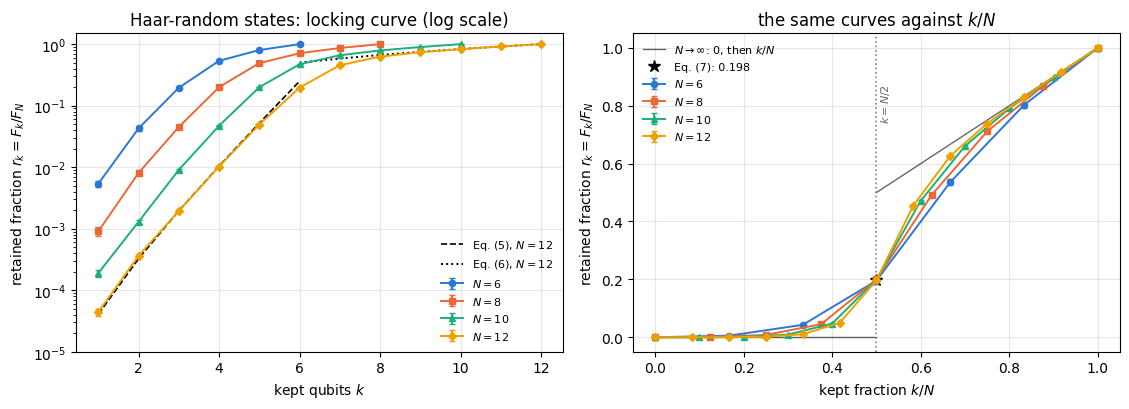

In [8]:
# ==============================================================================
# FIGURE: the Haar locking curve, absolute and rescaled
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for j, n in enumerate(N_HAAR):
    ks = np.arange(n + 1)
    axes[0].errorbar(ks[1:], haar_mean[n][1:], yerr=haar_sem[n][1:], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=f"$N={n}$")
    axes[1].errorbar(ks / n, haar_mean[n], yerr=haar_sem[n], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=f"$N={n}$")
n = N_HAAR[-1]
k_lo, k_hi = np.arange(1, n // 2 + 1), np.arange(n // 2, n + 1)
axes[0].plot(k_lo, k_lo * 4.0 ** k_lo / (2 * n * 2.0 ** n), "k--", lw=1.2, label=f"Eq. (5), $N={n}$")
axes[0].plot(k_hi, k_hi / n, "k:", lw=1.4, label=f"Eq. (6), $N={n}$")
axes[0].set_yscale("log")
axes[0].set_ylim(1e-5, 1.5)
axes[1].plot([0, 0.5], [0, 0], "k-", lw=1.0, alpha=0.6)
axes[1].plot([0.5, 1.0], [0.5, 1.0], "k-", lw=1.0, alpha=0.6, label=r"$N\to\infty$: $0$, then $k/N$")
axes[1].plot([0.5], [R_MID], "k*", ms=9, label=f"Eq. (7): {R_MID:.3f}")
axes[0].set_xlabel("kept qubits $k$")
axes[1].set_xlabel("kept fraction $k/N$")
axes[1].axvline(0.5, color="0.5", ls=":", lw=1.2)
axes[1].text(0.505, 0.75, "$k=N/2$", fontsize=8, color="0.4", rotation=90)
for ax in axes:
    ax.set_ylabel(r"retained fraction $r_k=F_k/F_N$")
    ax.legend(fontsize=8)
axes[0].set_title("Haar-random states: locking curve (log scale)")
axes[1].set_title("the same curves against $k/N$")
fig.tight_layout()
plt.show()

The checkpoint confirms the three formulas: the midpoint sits at the Marchenko-Pastur value of Eq. (7) at every
$N$, two qubits below it Eq. (5) holds to within the statistical error, and the local slope
$r_{N/2-1}/r_{N/2-3}$ follows $16(N/2-1)/(N/2-3)$ of Eq. (5), not the factor $16$ of a constant suppression by four
per qubit. Three qubits above the threshold $F_k$ equals $k$ to a few per cent, Eq. (6), and $r_{N-1}$ stays near
$(N-1)/N$, far from the value $1$ that an "all or nothing" threshold would give. The left panel (log scale) shows
Eqs. (5) and (6) against the data at $N=12$; the right panel shows the limiting shape at fixed $k/N$.

This is the fixed point that the rest of this notebook watches two very different dynamics approach. Information
about a global property of a random state is not stored in small blocks, and the information that large blocks
hold is only the standard-quantum-limit share of their own qubits.

> **Common pitfall.** The ratio $r_k$ was formed *inside* each realisation and only then averaged. Averaging
> $F_k$ and $F_N$ separately and dividing afterwards is a different estimator, and with an unknown distribution of
> $F_N$ the two need not agree. For Haar states they do: the standard deviation of $F_N$ is
> $\sqrt{2N(N-1)/(d+1)}\approx0.25$ at $N=12$ (notebook 35), two per cent of its mean, and the measured difference
> printed above is a small fraction of one standard error. For the disordered chain of Section 5, where $F_N$
> varies between realisations, the per-realisation ratio is the quantity that answers the question "what fraction
> of *this* probe's information does the block hold", so it is used throughout.

### 4.3 The other protocol: phase imprinted before the scrambler

If the phase is imprinted *first* and the scrambler $U$ acts afterwards, the state is
$Ue^{-i\theta J_z}\vert\psi_0\rangle=e^{-i\theta UJ_zU^\dagger}U\vert\psi_0\rangle$: the scrambled state with the rotated generator
$UJ_zU^\dagger$. Now the invariance identity applies, $F_N=F_Q[\psi_0,J_z]$ is unchanged, and for a GHZ probe it
stays $N^2$. For a Haar-random $U$ the pair $\left(U\vert\mathrm{GHZ}\rangle,\,UJ_z\vert\mathrm{GHZ}\rangle\right)$ is distributed
exactly as $\left(e_1,\tfrac N2e_2\right)$ with $e_1,e_2$ a Haar-random orthonormal pair, because
$J_z\vert\mathrm{GHZ}\rangle$ is orthogonal to $\vert\mathrm{GHZ}\rangle$ and has norm $N/2$. No $2^N\times2^N$ unitary is needed: we feed
$(\psi,\phi)=(e_1,\tfrac N2e_2)$ to the same routine.

The small-block estimate is a one-line variant of Section 4.1: $F_k\approx d_A\,\mathrm{Tr}(\partial_\theta\rho_k)^2$ and, to
leading order, $\mathbb{E}\,\mathrm{Tr}(\partial_\theta\rho_k)^2\approx2\,\Vert\phi\Vert^2/d_B=N^2/(2d_B)$, so

$$r_k^{\mathrm{rot}}\approx\frac{d_A}{2d_B}=\frac{4^k}{2\cdot2^N}\qquad(k\le N/2). \tag{8}$$

This curve does fall by exactly four per qubit, and it reaches $1/2$ at $k=N/2$.

In [9]:
# ==============================================================================
# STEP 2b: locking curve for the ROTATED generator (phase imprinted before a Haar scrambler)
# ==============================================================================
def orthonormal_haar_pair(key, n):
    """Two orthonormal Haar-distributed state tensors (e1, e2): Gram-Schmidt on two complex Gaussian vectors."""
    k1, k2 = jax.random.split(key)
    e1, v = haar_state(k1, n), haar_state(k2, n)
    v = v - jnp.vdot(e1, v) * e1
    return e1, v / jnp.linalg.norm(v)


n = N_HAAR[-1]
rot_rows = []
for r in range(R_HAAR):
    key, sk = jax.random.split(key)
    e1, e2 = orthonormal_haar_pair(sk, n)
    phi = 0.5 * n * e2                                   # U J_z |GHZ>,  norm N/2, orthogonal to U|GHZ>
    rot_rows.append([0.0] + [float(_qfi_at_k(k)(e1, phi)) for k in range(1, n + 1)])
rot_rows = np.array(rot_rows)
rot_mean = (rot_rows / rot_rows[:, -1:]).mean(0)
print(f"F_N for the rotated generator: {rot_rows[:, -1].mean():.6f}  (N^2 = {n ** 2})")
print(f"\n  {'k':>3} {'r_k rotated':>12} {'Eq. (8)':>9} {'r_k + r_(N-k)':>14} | {'r_k fixed J_z':>14}")
for k in range(1, n):
    eq8 = 4.0 ** k / (2 * 2.0 ** n) if k <= n // 2 else np.nan
    print(f"  {k:>3} {rot_mean[k]:12.5f} {eq8:9.5f} {rot_mean[k] + rot_mean[n - k]:14.4f} | {haar_mean[n][k]:14.5f}")
assert abs(rot_rows[:, -1].mean() - n ** 2) < 1e6 * TOL               # invariance: F_N = N^2 exactly
for k in (n // 2 - 2, n // 2 - 1, n // 2):
    assert abs(rot_mean[k] / (4.0 ** k / (2 * 2.0 ** n)) - 1) < 0.1     # Eq. (8)
assert rot_mean[n // 2 + 2] > 0.9 and haar_mean[n][n // 2 + 2] < 0.75   # the step exists only for the rotated generator

F_N for the rotated generator: 144.000000  (N^2 = 144)

    k  r_k rotated   Eq. (8)  r_k + r_(N-k) |  r_k fixed J_z
    1      0.00040   0.00049         1.0000 |        0.00004
    2      0.00190   0.00195         1.0001 |        0.00036
    3      0.00775   0.00781         1.0001 |        0.00194
    4      0.03075   0.03125         0.9997 |        0.01024
    5      0.12449   0.12500         0.9988 |        0.04938
    6      0.49886   0.50000         0.9977 |        0.19686
    7      0.87427       nan         0.9988 |        0.45501
    8      0.96898       nan         0.9997 |        0.62649
    9      0.99232       nan         1.0001 |        0.73838
   10      0.99818       nan         1.0001 |        0.83018
   11      0.99964       nan         1.0000 |        0.91676


The two protocols share the threshold at $k=N/2$ and nothing else. With the phase imprinted before the
scrambler, $F_N=N^2$ is preserved exactly; half of the register holds half of it, every qubit removed below the
threshold costs a factor of four, Eq. (8), and every qubit added above it brings the block closer to everything.
The measured curve also satisfies $r_k+r_{N-k}\approx1$, so a block and its complement share the information.
This is the sharp threshold of the Hayden-Preskill analysis of scrambled systems. With the phase imprinted after
the scrambler, the subject of the rest of this notebook, the total information has already collapsed to
$F_N\approx N$, and the large blocks hold only their standard-quantum-limit share of it.

## 5. The analog scrambler: a chaotic spin chain

### 5.1 The Hamiltonian

The analog route stirs the probe by simply letting it evolve. The chain is

$$H_{\text{scr}}=J\sum_{q=0}^{N-2}\left(X_qX_{q+1}+Y_qY_{q+1}\right)+\sum_{q=0}^{N-1}h_qX_q,
\qquad h_q\ \text{drawn uniformly from}\ [-h,h], \tag{4}$$

an open $XX$ chain in a **random transverse field**. The choice is deliberate on both counts.

The bare $XX+YY$ chain is *integrable*: a Jordan-Wigner transformation maps it to free fermions, it conserves
$\sum_qZ_q$, and it does not scramble — it spreads excitations ballistically but it does not make the state
generic. Adding a field along $x$ breaks the conservation of $\sum_qZ_q$ and destroys the free-fermion
structure, and the chain becomes non-integrable. Making the field **random** removes the translation invariance
that would otherwise give extra structure to the spectrum, and it lets us average over disorder realisations
instead of over nothing.

The bare chain ($h=0$) serves as a control. On the GHZ probe it does nothing at all, for a reason that is
simpler than integrability and is derived in Section 5.5.

### 5.2 Integrating it

$H_{\text{scr}}$ is a sum of two-site bond terms and one-site field terms, which is exactly the input format of
the engine's `tebd_gates`: one second-order Trotter-Suzuki step is a list of small unitaries applied by einsum,
and `lax.scan` runs the step $n$ times inside XLA after compiling it once.

The step size must be chosen, not assumed. The second-order splitting has a global error $O(dt^2)$, but the
prefactor depends on the commutators of the terms, and the disorder strength enters it. So we measure: evolve
to a fixed time with decreasing $dt$, compare against the smallest one, and confirm the slope is $2$ before
trusting any of the physics. The error accumulates over the run, roughly linearly in time, so at the step chosen
below it is of order $10^{-2}$ in the state norm by $Jt=16$. The Trotterised evolution is then a slightly
different chaotic dynamics; the statements made below are about scrambling, which both dynamics share, and not
about the exact state at $Jt=16$.

In [10]:
# ==============================================================================
# STEP 3: the chaotic chain and its Trotter step
# ==============================================================================
J_SCR = 1.0            # bond coupling of Eq. (4)
H_SCR = 1.0            # disorder strength of the transverse field


def scrambler_terms(key, n, h=H_SCR, j=J_SCR):
    """Local terms of Eq. (4): open XX+YY bonds plus a random transverse field.

    Returns the engine's term format [(qubits, small hermitian matrix), ...]; h = 0 gives the
    integrable free-fermion chain used as the control in Section 5.5.
    """
    fields = jax.random.uniform(key, (n,), minval=-h, maxval=h)
    terms = [((q, q + 1), j * (XX + YY)) for q in range(n - 1)]
    terms += [((q,), float(fields[q]) * X) for q in range(n)]
    return terms


def make_stepper(terms, dt, order=2):
    """A jitted single Trotter-Suzuki step, and a jitted n-step propagator built with lax.scan.

    JAX    the gate list is a Python list of concrete arrays closed over by the step function, so it is
           baked into the compiled program; `lax.scan` then loops inside XLA instead of unrolling n
           copies of the circuit at trace time.
    """
    gates = tebd_gates(terms, dt, order=order)
    step = jax.jit(lambda p: apply_gates(p, gates))

    @partial(jax.jit, static_argnums=1)
    def evolve(p, n_steps):
        return lax.scan(lambda s, _: (apply_gates(s, gates), None), p, None, length=n_steps)[0]

    return step, evolve


# --- CHECKPOINT: the Trotter step is unitary and the order is 2, measured ---------------
key, sk = jax.random.split(key)
terms_chk = scrambler_terms(sk, N)
T_CHK = 1.0
dts = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
ref_step, ref_evolve = make_stepper(terms_chk, 0.0015625)
psi_ref = ref_evolve(psi_ghz, int(round(T_CHK / 0.0015625)))
errs = []
for dt in dts:
    _, ev = make_stepper(terms_chk, float(dt))
    out = ev(psi_ghz, int(round(T_CHK / dt)))
    errs.append(float(jnp.linalg.norm((out - psi_ref).reshape(-1))))
errs = np.array(errs)
slope = np.polyfit(np.log(dts), np.log(errs), 1)[0]
print(f"norm after evolution: {float(jnp.vdot(psi_ref, psi_ref).real):.12f}  (must be 1)")
print(f"\n  {'dt':>8} {'||psi(dt) - psi_ref||':>24}")
for dt, e in zip(dts, errs):
    print(f"  {dt:8.5f} {e:24.3e}")
print(f"\nfitted convergence order = {slope:.3f}   (second-order Trotter-Suzuki: 2)")
assert abs(slope - 2.0) < 0.15
assert abs(float(jnp.vdot(psi_ref, psi_ref).real) - 1.0) < 1e6 * TOL

DT_SCR = 0.02          # step size used from here on: dt^2 scaling of the table puts the error at t = 1 near 5e-4

norm after evolution: 0.999999999994  (must be 1)

        dt    ||psi(dt) - psi_ref||
   0.20000                5.332e-02
   0.10000                1.333e-02
   0.05000                3.330e-03
   0.02500                8.300e-04
   0.01250                2.051e-04

fitted convergence order = 2.005   (second-order Trotter-Suzuki: 2)


### 5.3 One compilation for all disorder realisations

The validation above built a fresh gate list for each $dt$ and let `jax.jit` bake it into the compiled program.
That is the right thing to do once. It is the wrong thing to do in a loop over disorder realisations: each
realisation has different field gates, so each closure is a different Python object, and JAX recompiles the
entire $46$-gate circuit every time. The fix is to make the disorder an **argument**.

The bond gate is the same on every bond and in every realisation, so it stays a constant. The field gates form
an array of shape $(N,2,2)$, which is passed in and traced. One compilation then serves every realisation and
every disorder strength.

Once the disorder is an argument, a second gain follows for free: `jax.vmap` maps the propagator over a whole
batch of realisations, so all six chains of Section 5.4 are evolved by one compiled, batched program rather
than by a Python loop over six.

We write the second-order step by hand in the same symmetric form the engine uses — the full sweep of half-step
gates followed by the reversed sweep — and check it against `tebd_gates` before using it.

In [11]:
# ==============================================================================
# STEP 4: a Trotter step whose disorder is an ARGUMENT, not a compile-time constant
# ==============================================================================
U_BOND_HALF = _expm_herm(J_SCR * (XX + YY), DT_SCR / 2)     # same on every bond: a constant


def analog_step(psi, u_field):
    """One second-order Trotter-Suzuki step of Eq. (4).

    MATH   S_2(dt) = (prod_k e^{-i h_k dt/2}) (prod_k e^{-i h_k dt/2})^{reversed}, the symmetric
           (Strang) product over all bond and field terms -- global error O(dt^2).
    ARGS   u_field : (N, 2, 2) array of single-site half-step propagators exp(-i h_q X dt/2).
    JAX    u_field is a traced ARGUMENT, so one compiled program serves every disorder realisation;
           the loops over q are unrolled at trace time into a single fused XLA program.
    """
    n = psi.ndim
    for q in range(n - 1):
        psi = apply_gate(psi, U_BOND_HALF, (q, q + 1))
    for q in range(n):
        psi = apply_gate(psi, u_field[q], (q,))
    for q in reversed(range(n)):
        psi = apply_gate(psi, u_field[q], (q,))
    for q in reversed(range(n - 1)):
        psi = apply_gate(psi, U_BOND_HALF, (q, q + 1))
    return psi


@partial(jax.jit, static_argnums=2)
def analog_evolve(psi, u_field, n_steps):
    """n_steps of `analog_step`, looped inside XLA with lax.scan (compiled once per n_steps)."""
    return lax.scan(lambda s, _: (analog_step(s, u_field), None), psi, None, length=n_steps)[0]


@partial(jax.jit, static_argnums=2)
def analog_evolve_batch(psis, u_fields, n_steps):
    """Evolve a BATCH of states, each under its own disorder realisation.

    JAX    `vmap` turns the single-state propagator into one that maps over the leading axis of both
           arguments. The circuit is compiled once and XLA runs the realisations as a batched program
           instead of as a Python loop -- the same work, one dispatch. Memory is R * 2^N amplitudes,
           which at N = 12 and R = 6 is under a megabyte.
    """
    def one(psi, u_field):
        return lax.scan(lambda st, _: (analog_step(st, u_field), None), psi, None, length=n_steps)[0]

    return jax.vmap(one)(psis, u_fields)


def field_propagators(key, n, h, dt=DT_SCR):
    """Half-step field propagators exp(-i h_q X dt/2) for uniformly random h_q in [-h, h]."""
    fields = jax.random.uniform(key, (n,), minval=-h, maxval=h)
    return jnp.stack([_expm_herm(float(fields[q]) * X, dt / 2) for q in range(n)])


# --- CHECKPOINT: the hand-written step equals the engine's generic one -----------------
key, sk = jax.random.split(key)
fields_chk = jax.random.uniform(sk, (N,), minval=-H_SCR, maxval=H_SCR)
terms_ref = ([((q, q + 1), J_SCR * (XX + YY)) for q in range(N - 1)]
             + [((q,), float(fields_chk[q]) * X) for q in range(N)])
ref_out = apply_gates(psi_ghz, tebd_gates(terms_ref, DT_SCR, order=2))
own_out = analog_step(psi_ghz, jnp.stack([_expm_herm(float(fields_chk[q]) * X, DT_SCR / 2)
                                          for q in range(N)]))
print(f"hand-written step vs engine tebd_gates: max |difference| = {max_abs(own_out - ref_out):.2e}")
assert max_abs(own_out - ref_out) < 1e6 * TOL

hand-written step vs engine tebd_gates: max |difference| = 0.00e+00


### 5.4 Locking in real time

The probe is the GHZ state: the most fragile probe there is, and the one whose locking curve starts as a step
function at $k=N$ — it is the state for which *every* proper subsystem carries exactly zero phase information,
because tracing out even one qubit leaves the classical mixture $\tfrac12(\vert0\cdots0\rangle\langle0\cdots0\vert
+\vert1\cdots1\rangle\langle1\cdots1\vert)$, a mixture of eigenstates of $J_z$, which does not move when the
phase is imprinted.

So at $t=0$ the locking curve is already "locked" in a trivial sense: $r_k=0$ for every $k<N$. What the chaotic
evolution does is *unlock* it first — the information spreads into subsystems and becomes readable from them —
and only then lock it again, this time into the Haar shape. The next table and figure follow both stages.

We record the locking curve, the total $F_N$ for the three collective axes, the half-chain entanglement entropy
and the entropy of the last three qubits at eleven times up to $Jt=16$, averaging over disorder realisations.

In [12]:
# ==============================================================================
# STEP 5: locking curve and entropy along the chaotic evolution
# ==============================================================================
CHUNK = 25                                     # Trotter steps between recordings: t = 0.5
REC_CHUNKS = [0, 1, 2, 3, 4, 6, 8, 12, 16, 24, 32]
T_REC = np.array(REC_CHUNKS) * CHUNK * DT_SCR  # 0, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 12, 16
R_DIS = 6                                      # disorder realisations, evolved together with vmap

ana_curves = np.zeros((R_DIS, len(REC_CHUNKS), N + 1))
ana_entropy = np.zeros((R_DIS, len(REC_CHUNKS)))
ana_FN = np.zeros((R_DIS, len(REC_CHUNKS), 3))           # total F_N for J_x, J_y, J_z
ana_S3 = np.zeros((R_DIS, len(REC_CHUNKS)))              # entropy of the block of the last 3 qubits
t0 = time.time()
key, *sub = jax.random.split(key, R_DIS + 1)     # sub holds exactly R_DIS independent keys
assert len(sub) == R_DIS
u_fields = jnp.stack([field_propagators(k, N, H_SCR) for k in sub])
psis = jnp.broadcast_to(psi_ghz, (R_DIS,) + psi_ghz.shape)

# --- CHECKPOINT: the batched propagator agrees with the single-state one ---------------
one_by_one = analog_evolve(psi_ghz, u_fields[0], CHUNK)
batched = analog_evolve_batch(psis, u_fields, CHUNK)[0]
print(f"vmapped evolution vs single-state evolution: max |difference| = "
      f"{max_abs(batched - one_by_one):.2e}")
assert max_abs(batched - one_by_one) < 1e6 * TOL

j = 0
for ci in range(max(REC_CHUNKS) + 1):
    if ci > 0:
        psis = analog_evolve_batch(psis, u_fields, CHUNK)
    if ci in REC_CHUNKS:
        for r in range(R_DIS):
            c = locking_curve(psis[r])
            ana_curves[r, j] = c / c[-1]
            ana_entropy[r, j] = half_entropy(psis[r])
            ana_FN[r, j] = [float(qfi_pure(psis[r], P)) for P in (X, Y, Z)]
            ana_S3[r, j] = float(entanglement_entropy(psis[r], range(N - 3, N)))
        j += 1
ana_mean, ana_sem = ana_curves.mean(0), ana_curves.std(0, ddof=1) / np.sqrt(R_DIS)
ent_mean, ent_sem = ana_entropy.mean(0), ana_entropy.std(0, ddof=1) / np.sqrt(R_DIS)
S_PAGE = page_entropy_bits(N // 2, N - N // 2)
print(f"analog scrambling of a GHZ probe, N = {N}, {R_DIS} disorder realisations, "
      f"{time.time() - t0:.1f} s\n")

print(f"  {'t':>6} {'F_N^z':>7} {'max_a F_N^a':>11} {'S_half/bits':>12} {'/Page':>7} | "
      + " ".join(f"{'k=' + str(k):>8s}" for k in range(1, 8)))
for j, t in enumerate(T_REC):
    print(f"  {t:6.1f} {ana_FN[:, j, 2].mean():7.2f} {ana_FN[:, j].max(1).mean():11.2f} {ent_mean[j]:12.3f} "
          f"{ent_mean[j] / S_PAGE:7.3f} | " + " ".join(f"{ana_mean[j][k]:8.4f}" for k in range(1, 8)))
print(f"\n  Haar reference (N = {N}):  {N * 2 ** N / (2 ** N + 1):7.2f} {'':32s}"
      + " ".join(f"{haar_mean[N][k]:8.4f}" for k in range(1, 8)))
print(f"  Page entropy for this cut: {S_PAGE:.3f} bits")

vmapped evolution vs single-state evolution: max |difference| = 0.00e+00


analog scrambling of a GHZ probe, N = 12, 6 disorder realisations, 10.1 s

       t   F_N^z max_a F_N^a  S_half/bits   /Page |      k=1      k=2      k=3      k=4      k=5      k=6      k=7
     0.0  144.00      144.00        1.000   0.189 |   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
     0.5  113.64      113.64        1.014   0.192 |   0.0005   0.0039   0.0051   0.0083   0.0104   0.0132   0.0148
     1.0   72.42       72.42        1.338   0.254 |   0.0042   0.0089   0.0205   0.0308   0.0384   0.0482   0.0582
     1.5   52.23       52.23        1.946   0.369 |   0.0053   0.0116   0.0283   0.0544   0.0754   0.0957   0.1173
     2.0   41.49       41.49        2.574   0.488 |   0.0059   0.0147   0.0320   0.0560   0.0939   0.1348   0.1742
     3.0   27.80       27.80        3.769   0.714 |   0.0027   0.0089   0.0241   0.0492   0.0948   0.1743   0.2730
     4.0   21.87       21.87        4.468   0.846 |   0.0014   0.0041   0.0104   0.0272   0.0697   0.1662   0.3128
     

The first two columns are the total. For the fixed generator $J_z$ the quantum Fisher information of the whole
register falls from $N^2=144$ to about $13$ by $Jt=16$, close to the Haar value $Nd/(d+1)\approx12$, and the best of
the three collective axes is no better: this is the collapse of notebook 35, now in real time. The locking
columns describe how the remaining information is distributed, each realisation normalised by its own $F_N$.

Read the table down each locking column. The small-$k$ columns show a two-stage history: a rise, as the phase
information leaks out of the global GHZ coherence into finite blocks of the chain, and then a fall, as it is
carried further and becomes global again. The large-$k$ columns show only the rise — for a block bigger than
half the chain there is nowhere further for the information to go, so it arrives and stays.

Rather than reading the turning points off the table by eye, we locate them.

In [13]:
# ==============================================================================
# STEP 5b: where each block is at its most informative
# ==============================================================================
print(f"  {'k':>3} {'peak r_k':>10} {'at Jt':>8} {'final r_k':>11} {'Haar':>9}   behaviour")
for k in range(1, N):                               # k = N is identically 1 and carries no information
    j = int(np.argmax(ana_mean[:, k]))
    peak, final = ana_mean[j, k], ana_mean[-1, k]
    if j == 0:
        what = "flat"
    elif final > 0.95 * peak:
        what = "rises and saturates"
    else:
        what = f"peaks, then falls to {final / peak:.2f} of the peak"
    print(f"  {k:>3} {ana_mean[j, k]:10.4f} {T_REC[j]:8.1f} {ana_mean[-1, k]:11.4f} "
          f"{haar_mean[N][k]:9.4f}   {what}")

    k   peak r_k    at Jt   final r_k      Haar   behaviour
    1     0.0059      2.0      0.0001    0.0000   peaks, then falls to 0.01 of the peak
    2     0.0147      2.0      0.0005    0.0004   peaks, then falls to 0.03 of the peak
    3     0.0320      2.0      0.0030    0.0019   peaks, then falls to 0.10 of the peak
    4     0.0560      2.0      0.0153    0.0102   peaks, then falls to 0.27 of the peak
    5     0.0948      3.0      0.0576    0.0494   peaks, then falls to 0.61 of the peak
    6     0.1975     12.0      0.1967    0.1969   rises and saturates
    7     0.4386     16.0      0.4386    0.4550   rises and saturates
    8     0.6192     16.0      0.6192    0.6265   rises and saturates
    9     0.7375     12.0      0.7350    0.7384   rises and saturates
   10     0.8332     12.0      0.8253    0.8302   rises and saturates
   11     0.9146     16.0      0.9146    0.9168   rises and saturates


The table splits the register in two at $k=N/2=6$. Every block smaller than half the chain rises to a maximum
and then decays back to within a factor of about three of the Haar value (closer for the larger blocks): the
information passes through it.
Every block of half the chain or more rises and saturates near its Haar value, which above the threshold is
the standard-quantum-limit share of Eq. (6).

The maxima fall at $Jt=2$ for the blocks of one to four qubits and at $Jt=3$ for five qubits. The recording grid
(spacing $J\Delta t=0.5$ up to $Jt=2$, coarser later) is too coarse to tell whether the maximum moves gradually with
the block size, as a front crossing the chain at finite speed would make it. Exercise 8 does the measurement on a finer grid and compares it with the light cone of
connected correlations of the same chain, measured by the method of notebook 15.

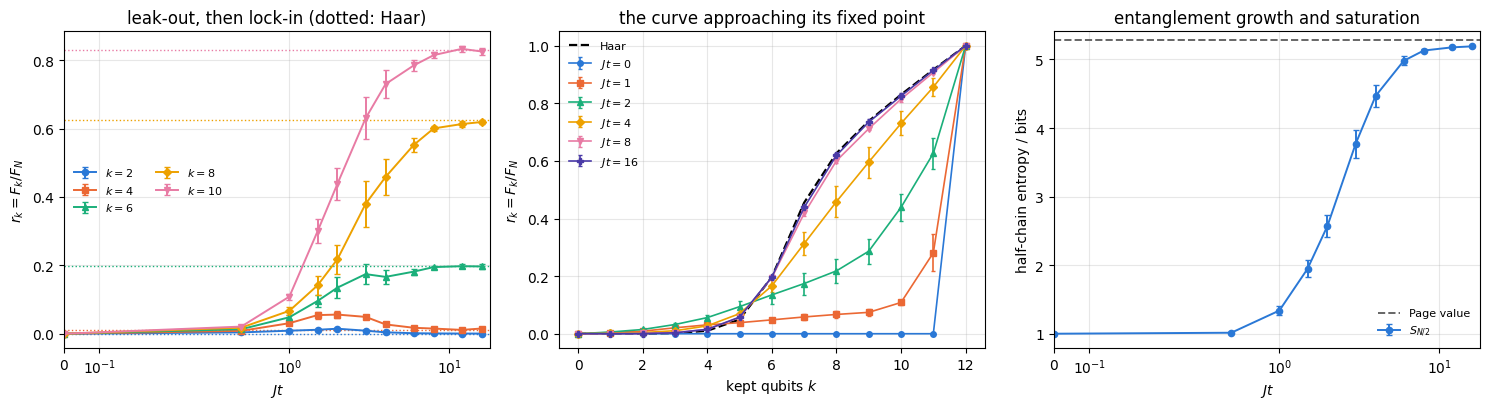

In [14]:
# ==============================================================================
# FIGURE: the two stages of analog locking
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))

for j, k in enumerate([2, 4, 6, 8, 10]):
    axes[0].errorbar(T_REC, ana_mean[:, k], yerr=ana_sem[:, k], fmt=MARKERS[j % 6] + "-",
                     color=PALETTE[j % 6], ms=4.5, lw=1.4, capsize=2, label=f"$k={k}$")
    axes[0].axhline(haar_mean[N][k], color=PALETTE[j % 6], ls=":", lw=1.0)
axes[0].set_xscale("symlog", linthresh=0.5)
axes[0].set_xlim(0, 18)
axes[0].set_xlabel("$Jt$")
axes[0].set_ylabel(r"$r_k=F_k/F_N$")
axes[0].set_title("leak-out, then lock-in (dotted: Haar)")
axes[0].legend(fontsize=8, ncol=2)

for j, ji in enumerate([0, 2, 4, 6, 8, 10]):
    axes[1].errorbar(np.arange(N + 1), ana_mean[ji], yerr=ana_sem[ji], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.0, lw=1.2, capsize=1.5, label=f"$Jt={T_REC[ji]:g}$")
axes[1].plot(np.arange(N + 1), haar_mean[N], "k--", lw=1.6, label="Haar")
axes[1].set_xlabel("kept qubits $k$")
axes[1].set_ylabel(r"$r_k=F_k/F_N$")
axes[1].set_title("the curve approaching its fixed point")
axes[1].legend(fontsize=8)

axes[2].errorbar(T_REC, ent_mean, yerr=ent_sem, fmt="o-", color=PALETTE[0], ms=4.5, lw=1.4,
                 capsize=2, label="$S_{N/2}$")
axes[2].axhline(S_PAGE, color="0.4", ls="--", lw=1.4, label="Page value")
axes[2].set_xscale("symlog", linthresh=0.5)
axes[2].set_xlim(0, 18)
axes[2].set_xlabel("$Jt$")
axes[2].set_ylabel("half-chain entropy / bits")
axes[2].set_title("entanglement growth and saturation")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

### 5.5 The scrambler that cannot scramble

Setting $h=0$ removes the field and leaves the bare $XX+YY$ chain. On this probe it does **nothing at all**, and
the reason is exact rather than statistical. On the two-site basis states,

$$\left(XX+YY\right)\vert00\rangle=\vert11\rangle-\vert11\rangle=0,\qquad
\left(XX+YY\right)\vert11\rangle=\vert00\rangle-\vert00\rangle=0,$$

because $Y\vert0\rangle=i\vert1\rangle$ and $Y\vert1\rangle=-i\vert0\rangle$ contribute a factor $i\cdot i=-1$
where $X\otimes X$ contributes $+1$. Every bond term annihilates both $\vert0\cdots0\rangle$ and
$\vert1\cdots1\rangle$, so $H_{\text{scr}}\vert\mathrm{GHZ}\rangle=0$ at $h=0$: the GHZ state is an exact
zero-energy eigenstate, a *dark state* of the bare chain. It does not evolve, it does not entangle further, and
it never locks.

The transverse field is what breaks this — it is simultaneously what makes the chain non-integrable and what
connects the GHZ state to the rest of the Hilbert space. Sweeping its strength therefore sweeps the scrambling
rate, and the sweep below shows a dark state, a slow scrambler and a fast one, all at the same final time.

In [15]:
# ==============================================================================
# STEP 6: the same evolution at four disorder strengths, compared at t = 16
# ==============================================================================
H_SWEEP = [0.0, 0.25, 1.0, 2.0]
R_SWEEP = 4
T_FINAL = 16.0
n_chunks_final = int(round(T_FINAL / (CHUNK * DT_SCR)))

sweep_mean, sweep_ent = {}, {}
t0 = time.time()
for h in H_SWEEP:
    rows, ents = [], []
    for r in range(R_SWEEP):
        key, sk = jax.random.split(key)
        u_field = field_propagators(sk, N, h)
        psi = psi_ghz
        for _ in range(n_chunks_final):
            psi = analog_evolve(psi, u_field, CHUNK)
        c = locking_curve(psi)
        rows.append(c / c[-1] if c[-1] > 0 else c)
        ents.append(half_entropy(psi))
    sweep_mean[h] = np.array(rows).mean(0)
    sweep_ent[h] = float(np.mean(ents))
print(f"disorder sweep at Jt = {T_FINAL:g}, {R_SWEEP} realisations each, {time.time() - t0:.1f} s\n")

print(f"  {'h':>5} {'S_half':>8} {'/Page':>7} | " + " ".join(f"{'k=' + str(k):>8s}" for k in range(1, 8)))
for h in H_SWEEP:
    print(f"  {h:5.2f} {sweep_ent[h]:8.3f} {sweep_ent[h] / S_PAGE:7.3f} | "
          + " ".join(f"{sweep_mean[h][k]:8.4f}" for k in range(1, 8)))
print(f"  {'Haar':>5} {S_PAGE:8.3f} {1.0:7.3f} | "
      + " ".join(f"{haar_mean[N][k]:8.4f}" for k in range(1, 8)))

# --- CHECKPOINT: at h = 0 the GHZ state is an exact eigenstate ------------------------
bond_only = [((q, q + 1), J_SCR * (XX + YY)) for q in range(N - 1)]
h_ghz = sum(apply_gate(psi_ghz, m, qs) for qs, m in bond_only)
print(f"\n|| H_bond |GHZ> || = {float(jnp.linalg.norm(h_ghz.reshape(-1))):.2e}   (dark state: exactly 0)")
assert float(jnp.linalg.norm(h_ghz.reshape(-1))) < 1e6 * TOL

disorder sweep at Jt = 16, 4 realisations each, 17.6 s

      h   S_half   /Page |      k=1      k=2      k=3      k=4      k=5      k=6      k=7
   0.00    1.000   0.189 |   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
   0.25    2.259   0.428 |   0.0001   0.0021   0.0053   0.0114   0.0161   0.0254   0.0359
   1.00    5.210   0.987 |   0.0001   0.0009   0.0029   0.0134   0.0495   0.1865   0.4406
   2.00    5.205   0.986 |   0.0002   0.0007   0.0038   0.0138   0.0565   0.2017   0.4412
   Haar    5.279   1.000 |   0.0000   0.0004   0.0019   0.0102   0.0494   0.1969   0.4550

|| H_bond |GHZ> || = 0.00e+00   (dark state: exactly 0)


The sweep shows the three regimes. At $h=0$ the state does not move: the entropy stays at the one bit of the GHZ
state and every proper block retains exactly nothing, because the probe is still the GHZ state. At $h=0.25$ the
chain scrambles slowly: by $Jt=16$ the half-chain entropy has reached less than half of the Page value, the
blocks of two and three qubits still hold several times the Haar share, and the blocks of five or more hold far
less than it. At $h=1$ and $h=2$ the entropy is within two per cent of Page and the curve is within a factor of
two of the Haar one at every $k\ge3$. Exercise 4 turns the sweep into a rate and asks what
happens when the field dominates the bonds.

## 6. Digital scramblers: three gate sets on the same geometry

The digital route replaces continuous evolution by discrete layers. The geometry is the brick wall of
notebook 10: layer $L$ acts with two-qubit gates on the bonds $(q,q+1)$ with $q\equiv L\ (\mathrm{mod}\ 2)$, so
that every qubit is touched every two layers and correlations spread at one site per layer. Depth $L$ plays the
role that time $t$ played in Section 5.

What changes between the three scramblers is only the gate set.

| scrambler | layer | what it can produce |
|---|---|---|
| Haar | a Haar-random $4\times4$ unitary on each brick-wall bond | generic states; the reference scrambler |
| Clifford | a random single-qubit Clifford on every site, then CNOT on each brick-wall bond | **stabilizer states only** |
| Clifford $+$ $n_T$ T | the Clifford layer plus $T$ gates on $n_T$ randomly chosen sites | stabilizer states doped with magic |

The middle row is the interesting one. By the Gottesman-Knill theorem (notebook 27) a Clifford circuit acting on
a stabilizer state — and $\vert\mathrm{GHZ}\rangle$ is one — produces a stabilizer state, which can be simulated
classically in polynomial time and which has **zero magic**. Such states are nonetheless highly entangled: a
random stabilizer state has close to the Page entropy. The Clifford scrambler therefore tests whether volume-law
entanglement alone produces the Haar locking curve, or whether locking also requires the genericity that magic
provides.

> **Physics insight.** A stabilizer state has a rigid structure: every reduced density matrix is proportional to
> a projector, its spectrum is flat, and its entropy is an integer number of bits. That rigidity propagates into
> the locking curve of every single realisation, which can only take values in a discrete set. Whether the
> *average* over realisations also differs from the Haar curve is a separate question, answered in Section 6.2.

In [16]:
# ==============================================================================
# STEP 7: the three digital layers
# ==============================================================================
CLIFFORDS = single_qubit_cliffords()            # the 24 single-qubit Cliffords, from the engine
N_T_DOPE = 2                                    # T gates per layer in the doped circuit


def brick_bonds(n, layer):
    """Bonds touched by brick-wall layer `layer` of an open chain of n qubits."""
    return [(q, q + 1) for q in range(layer % 2, n - 1, 2)]


def layer_haar(key, psi, layer):
    """One brick-wall layer of Haar-random two-qubit gates."""
    for b in brick_bonds(psi.ndim, layer):
        key, sub = jax.random.split(key)
        psi = apply_gate(psi, haar_unitary(sub, 4), b)
    return psi


def layer_clifford(key, psi, layer, n_t=0):
    """One brick-wall Clifford layer, optionally doped with n_t T gates on random sites.

    A random single-qubit Clifford on every site, then CNOT on every bond of the layer. With n_t = 0
    the circuit maps stabilizer states to stabilizer states; each T gate injects one unit of magic.
    """
    n = psi.ndim
    k1, k2 = jax.random.split(key)
    idx = jax.random.randint(k1, (n,), 0, len(CLIFFORDS))
    for q in range(n):
        psi = apply_gate(psi, CLIFFORDS[idx[q]], (q,))
    if n_t > 0:
        sites = np.asarray(jax.random.choice(k2, n, (n_t,), replace=False))
        for q in sites:
            psi = apply_gate(psi, T, (int(q),))
    for b in brick_bonds(n, layer):
        psi = apply_gate(psi, CNOT, b)
    return psi


DIGITAL = {"Haar": layer_haar,
           "Clifford": partial(layer_clifford, n_t=0),
           f"Clifford + {N_T_DOPE}T": partial(layer_clifford, n_t=N_T_DOPE)}

In [17]:
# ==============================================================================
# STEP 8: locking curve and entropy versus circuit depth
# ==============================================================================
DEPTHS = [0, 1, 2, 3, 4, 6, 8, 12, 16, 24, 32]
R_CIRC = 6                                       # circuit realisations per gate set

dig_mean, dig_sem, dig_ent, dig_ent_raw, dig_FN, dig_S3, dig_raw = {}, {}, {}, {}, {}, {}, {}
t0 = time.time()
for name, layer in DIGITAL.items():
    raw = np.zeros((R_CIRC, len(DEPTHS), N + 1))     # F_k themselves; F_N = raw[..., -1]
    ents = np.zeros((R_CIRC, len(DEPTHS)))
    s3 = np.zeros((R_CIRC, len(DEPTHS)))
    for r in range(R_CIRC):
        key, sk = jax.random.split(key)
        psi, j = psi_ghz, 0
        for L in range(max(DEPTHS) + 1):
            if L > 0:
                sk, sub = jax.random.split(sk)
                psi = layer(sub, psi, L - 1)
            if L in DEPTHS:
                raw[r, j] = locking_curve(psi)
                ents[r, j] = half_entropy(psi)
                s3[r, j] = float(entanglement_entropy(psi, range(N - 3, N)))
                j += 1
    curves = raw / raw[..., -1:]
    dig_raw[name] = raw
    dig_mean[name] = curves.mean(0)
    dig_sem[name] = curves.std(0, ddof=1) / np.sqrt(R_CIRC)
    dig_ent[name] = ents.mean(0)
    dig_ent_raw[name] = ents
    dig_FN[name] = raw[..., -1].mean(0)
    dig_S3[name] = s3.mean(0)
print(f"three digital scramblers, {R_CIRC} circuit realisations each, {time.time() - t0:.1f} s\n")

for name in DIGITAL:
    print(f"  --- {name} ---")
    print(f"  {'L':>4} {'F_N^z':>7} {'S_half':>8} {'/Page':>7} | " + " ".join(f"{'k=' + str(k):>8s}" for k in range(1, 8)))
    for j, L in enumerate(DEPTHS):
        print(f"  {L:4d} {dig_FN[name][j]:7.2f} {dig_ent[name][j]:8.3f} {dig_ent[name][j] / S_PAGE:7.3f} | "
              + " ".join(f"{dig_mean[name][j][k]:8.4f}" for k in range(1, 8)))
    print()
print(f"  {'Haar reference':>21s} {'':15s} | " + " ".join(f"{haar_mean[N][k]:8.4f}" for k in range(1, 8)))

# --- CHECKPOINT: Clifford realisations have INTEGER half-chain entropy and INTEGER F_k ------
cliff_ents = dig_ent_raw["Clifford"]
dev = float(np.max(np.abs(cliff_ents - np.round(cliff_ents))))
dev_f = float(np.max(np.abs(dig_raw["Clifford"] - np.round(dig_raw["Clifford"]))))
dev_f_doped = float(np.max(np.abs(dig_raw[f"Clifford + {N_T_DOPE}T"] - np.round(dig_raw[f"Clifford + {N_T_DOPE}T"]))))
print(f"\nClifford circuits: max deviation of S_half from an integer number of bits = {dev:.2e}")
print(f"Clifford circuits: max deviation of every F_k from an integer               = {dev_f:.2e}")
print(f"  (doped circuits, for contrast: max deviation of F_k from an integer = {dev_f_doped:.2f};")
print(f"   Haar circuits at depth {DEPTHS[-1]}: S_half = {dig_ent['Haar'][-1]:.4f} bits, Page = {S_PAGE:.4f})")
assert dev < 1e6 * TOL and dev_f < 1e6 * TOL
assert dev_f_doped > 0.1                      # the test can fail: one T gate already breaks integrality

three digital scramblers, 6 circuit realisations each, 13.4 s

  --- Haar ---
     L   F_N^z   S_half   /Page |      k=1      k=2      k=3      k=4      k=5      k=6      k=7
     0  144.00    1.000   0.189 |   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000   0.0000
     1    9.79    1.000   0.189 |   0.0105   0.1290   0.2016   0.3106   0.3510   0.4901   0.5237
     2   11.24    2.021   0.383 |   0.0094   0.0517   0.1885   0.2227   0.3669   0.4131   0.5276
     3   11.77    2.021   0.383 |   0.0086   0.0615   0.1230   0.2570   0.3132   0.4487   0.4968
     4   11.50    2.771   0.525 |   0.0079   0.0299   0.1347   0.1937   0.3230   0.3862   0.5157
     6   12.00    3.504   0.664 |   0.0035   0.0117   0.0810   0.1326   0.2757   0.3511   0.4888
     8   12.43    4.028   0.763 |   0.0023   0.0087   0.0440   0.0837   0.2268   0.3153   0.4689
    12   12.10    4.818   0.913 |   0.0005   0.0029   0.0185   0.0432   0.1384   0.2616   0.4707
    16   12.05    5.113   0.969 |   0.0002   0.00

The $F_N^z$ column is the total for the fixed generator. One layer of any of the three gate sets already
removes the Heisenberg value: $F_N^z$ drops from $144$ to about $10$–$12$ after the first layer and stays
near $N=12$ from then on. Section 6.1
checks this against the exact first-layer law of notebook 35.

The Clifford block is the one to read carefully. Its entanglement entropy climbs to within a few per cent of the
Page value, and the checkpoint confirms what the physics insight above predicts for every single realisation:
the half-chain entropy is an integer number of bits and every $F_k$ is an integer. In the averaged table the
small-$k$ Clifford entries at depth $32$ are exactly zero, while the doped and Haar circuits give small non-zero
numbers close to the Haar reference. Six realisations cannot tell whether the zeros are a property of the
Clifford ensemble or of the six circuits drawn; Section 6.2 settles it.

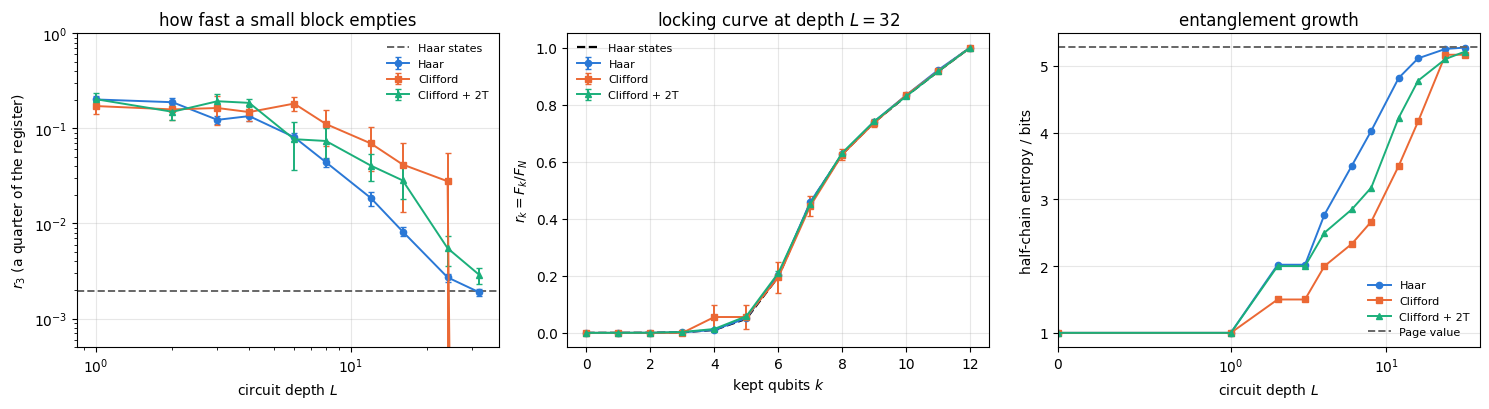

In [18]:
# ==============================================================================
# FIGURE: three gate sets, same geometry
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))

for j, name in enumerate(DIGITAL):
    r3 = dig_mean[name][1:, 3]
    axes[0].errorbar(DEPTHS[1:], np.where(r3 > 0, r3, np.nan), yerr=dig_sem[name][1:, 3],
                     fmt=MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=name)
axes[0].axhline(haar_mean[N][3], color="0.4", ls="--", lw=1.4, label="Haar states")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_ylim(5e-4, 1)
axes[0].set_xlabel("circuit depth $L$")
axes[0].set_ylabel("$r_3$ (a quarter of the register)")
axes[0].set_title("how fast a small block empties")
axes[0].legend(fontsize=8)

ks = np.arange(N + 1)
for j, name in enumerate(DIGITAL):
    axes[1].errorbar(ks, dig_mean[name][-1], yerr=dig_sem[name][-1], fmt=MARKERS[j] + "-",
                     color=PALETTE[j], ms=4.5, lw=1.4, capsize=2, label=name)
axes[1].plot(ks, haar_mean[N], "k--", lw=1.6, label="Haar states")
axes[1].set_xlabel("kept qubits $k$")
axes[1].set_ylabel(r"$r_k=F_k/F_N$")
axes[1].set_title(f"locking curve at depth $L={DEPTHS[-1]}$")
axes[1].legend(fontsize=8)

for j, name in enumerate(DIGITAL):
    axes[2].plot(DEPTHS, dig_ent[name], MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, label=name)
axes[2].axhline(S_PAGE, color="0.4", ls="--", lw=1.4, label="Page value")
axes[2].set_xscale("symlog", linthresh=1.0)
axes[2].set_xlim(0, 40)
axes[2].set_xlabel("circuit depth $L$")
axes[2].set_ylabel("half-chain entropy / bits")
axes[2].set_title("entanglement growth")
axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel starts at depth $L=1$ (at $L=0$ every $r_k$ with $k<N$ is zero). On its logarithmic axis a
realisation average that is exactly zero has no point; this is why the Clifford curve breaks off at large depth.

### 6.1 The first layer, against notebook 35

Notebook 35 derived what disjoint Haar-random two-qubit gates do to a cat state: after $g$ gates the average
quantum Fisher information along the cat axis is $(N-2g)^2+28g/15$ (its Eq. (11)). The derivation uses only the
Haar invariance of each gate, so it applies to the GHZ state along $z$ as well as to the cat along $x$ of that
notebook. The first brick-wall layer of this notebook acts on the $N/2$ disjoint bonds $(0,1),(2,3),\dots$, so
$g=N/2$ and the prediction is $\mathbb{E}F_N^z=14N/15=11.2$ at $N=12$, slightly *below* the Haar value
$Nd/(d+1)\approx12$.

In [19]:
# ==============================================================================
# CHECKPOINT: one Haar layer on the GHZ state, against Eq. (11) of notebook 35
# ==============================================================================
R_LAYER1 = 400
layer1 = jax.jit(lambda k, p: layer_haar(k, p, 0))
f1 = []
for r in range(R_LAYER1):
    key, sk = jax.random.split(key)
    f1.append(float(qfi_pure(layer1(sk, psi_ghz), Z)))
f1 = np.array(f1)
m1, s1 = f1.mean(), f1.std(ddof=1) / np.sqrt(R_LAYER1)
pred1, haar1 = 14 * N / 15, N * 2 ** N / (2 ** N + 1)
print(f"one Haar layer, {R_LAYER1} circuits: E F_N^z = {m1:.3f} +- {s1:.3f}")
print(f"  notebook 35, Eq. (11) with g = N/2:  14N/15  = {pred1:.3f}   ({(m1 - pred1) / s1:+.2f} sigma)")
print(f"  wrong control, Haar value:  Nd/(d+1) = {haar1:.3f}   ({(m1 - haar1) / s1:+.2f} sigma)")
assert abs(m1 - pred1) < 4 * s1
assert abs(m1 - haar1) > 4 * s1

one Haar layer, 400 circuits: E F_N^z = 11.268 +- 0.122
  notebook 35, Eq. (11) with g = N/2:  14N/15  = 11.200   (+0.56 sigma)
  wrong control, Haar value:  Nd/(d+1) = 11.997   (-5.98 sigma)


The measured mean agrees with notebook 35 and is separated from the Haar value by several standard errors: one
layer of local gates already destroys the Heisenberg scaling of the total, and the remaining layers move the
total only by about one unit, up to the Haar value. Everything that happens after the first layer is
redistribution, and that is what the locking curve resolves.

### 6.2 The Clifford average

Eqs. (5) and (6) used only the second moment $\mathbb{E}[\vert\psi\rangle\langle\psi\vert^{\otimes2}]$. Any ensemble of states that
reproduces this moment, a *state 2-design*, therefore has the same leading-order mean locking curve as Haar
states. Uniformly random stabilizer states form such a design, because the Clifford group is a unitary 2-design
(Roberts and Yoshida 2017 give a proof; quoted here without one), and a deep random
Clifford circuit approaches that uniform distribution. The prediction is that the Clifford **mean** is the
Haar curve, while each realisation is integer-valued, so that for small blocks most realisations give exactly
zero and a few give a large value. Six realisations are not enough to see the rare non-zero ones, so we draw many
more circuits at depth $32$.

In [20]:
# ==============================================================================
# STEP 8b: the Clifford ensemble at depth 32 -- mean, and the distribution behind it
# ==============================================================================
R_CL = 48
t0 = time.time()
cl_raw = []
for r in range(R_CL):
    key, sk = jax.random.split(key)
    psi = psi_ghz
    for L in range(DEPTHS[-1]):
        sk, sub = jax.random.split(sk)
        psi = layer_clifford(sub, psi, L)
    cl_raw.append(locking_curve(psi))
cl_raw = np.array(cl_raw)
cl_r = cl_raw / cl_raw[:, -1:]
cl_mean, cl_sem = cl_r.mean(0), cl_r.std(0, ddof=1) / np.sqrt(R_CL)
print(f"{R_CL} Clifford circuits of depth {DEPTHS[-1]} in {time.time() - t0:.1f} s;  F_N values: "
      f"{sorted(int(v) for v in set(np.round(cl_raw[:, -1])))}\n")
# If the Clifford mean equals the Haar mean, and every non-zero F_k is at least 1, the expected number of
# non-zero realisations is at most R_CL * F_N * r_k(Haar): a column of zeros is then no evidence against Haar.
print(f"  {'k':>3} {'Clifford mean r_k':>18} {'sem':>8} {'Haar r_k':>9} {'z':>6} {'non-zero':>9} "
      f"{'<= expected':>12}   values of F_k")
for k in range(1, N):
    n_nz = int(np.sum(cl_raw[:, k] > 0.5))
    z = (f"{(cl_mean[k] - haar_mean[N][k]) / np.hypot(cl_sem[k], haar_sem[N][k]):+6.2f}" if n_nz > 1
         else f"{'-':>6s}")
    expct = f"{R_CL * N * haar_mean[N][k]:12.1f}" if k < N // 2 else f"{'-':>12s}"
    vals = sorted(int(v) for v in set(np.round(cl_raw[:, k])))
    print(f"  {k:>3} {cl_mean[k]:18.5f} {cl_sem[k]:8.5f} {haar_mean[N][k]:9.5f} {z} {n_nz:9d} {expct}   {vals}")
assert np.max(np.abs(cl_raw - np.round(cl_raw))) < 1e6 * TOL                 # integer F_k, every realisation
for k in range(N // 2 - 1, N):                                               # blocks where non-zero values are common
    assert abs(cl_mean[k] - haar_mean[N][k]) < 4 * np.hypot(cl_sem[k], haar_sem[N][k])
assert np.any(cl_raw[:, 2:N // 2] > 0.5)     # wrong control "Clifford r_k = 0 below the threshold" must fail

# --- the fluctuations: relative spread of r_k between realisations at depth 32 ----------
print(f"\nrelative standard deviation of r_k between realisations (depth {DEPTHS[-1]}):")
spread = {"Clifford": cl_r}
spread.update({nm: dig_raw[nm][:, -1] / dig_raw[nm][:, -1, -1:] for nm in ("Haar", f"Clifford + {N_T_DOPE}T")})
for nm, rr in spread.items():
    print(f"  {nm:>14s}: " + "  ".join(f"k={k}: {rr[:, k].std(ddof=1) / rr[:, k].mean():5.2f}"
                                      for k in (4, 5, 6)))

48 Clifford circuits of depth 32 in 32.2 s;  F_N values: [12]

    k  Clifford mean r_k      sem  Haar r_k      z  non-zero  <= expected   values of F_k
    1            0.00000  0.00000   0.00004      -         0          0.0   [0]
    2            0.00000  0.00000   0.00036      -         0          0.2   [0]
    3            0.00000  0.00000   0.00194      -         0          1.1   [0]
    4            0.01042  0.00639   0.01024  +0.03         3          5.9   [0, 1, 2, 3]
    5            0.07813  0.01796   0.04938  +1.60        16         28.4   [0, 1, 2, 3, 4, 5]
    6            0.22743  0.02669   0.19686  +1.14        34            -   [0, 1, 2, 3, 4, 5, 6]
    7            0.47743  0.01462   0.45501  +1.52        48            -   [2, 4, 5, 6, 7]
    8            0.62326  0.00784   0.62649  -0.40        48            -   [6, 7, 8]
    9            0.73611  0.00517   0.73838  -0.41        48            -   [7, 8, 9]
   10            0.82639  0.00336   0.83018  -1.01        48 

The table answers the question of Section 6. Where non-zero values are common ($k\ge N/2-1$) the Clifford mean
agrees with the Haar curve within the standard errors. Below that the Clifford mean rests on a handful of
non-zero realisations: the blocks of four qubits retain one to a few units of $F_k$ in a few circuits out of
$48$, and the smaller blocks retain nothing in any of them. The column "expected" shows that this is what the Haar
mean predicts: a non-zero $F_k$ is at least $1$, so a mean equal to the Haar value allows at most about one
non-zero realisation of a three-qubit block among $48$, and fewer for smaller blocks. The staircase is a property
of each realisation: $F_k$ takes only the integer values listed, and a block of $k<N/2$ qubits is *usually*
exactly maximally mixed (then $F_k=0$) and *occasionally* retains a large share.

So the locking curve averaged over circuits does **not** distinguish Clifford from Haar scrambling, as the
2-design argument predicts. Magic shows up in the fluctuations, as the last table shows: the relative spread of
$r_k$ between realisations is a few per cent for Haar circuits, of order one or larger for Clifford circuits,
and in between for the doped circuits, where two $T$ gates per layer (two of the eighteen gates of a layer) make
the values non-integer and the small-$k$ entries of a single realisation small rather than zero.

## 7. The volume law as the mechanism, block by block

The mechanism proposed in Section 1 was the volume law: locking should follow entanglement. Sections 5 and 6
both produced entropies that climb to the Page value and locking curves that approach the Haar shape, which is
consistent. This section makes the connection quantitative and tests it, including the timing of the two.

First the structural check. The entanglement entropy of a random pure state is not proportional to $k$ for all
$k$ — it follows the Page curve, which is close to $k$ bits for $k<N/2$ (volume law, the small block is nearly
maximally mixed) and bends over to the same value on the other side by purity. We compute the full profile
$S_k$ for the final state of every scrambler and compare with Page.

In [21]:
# ==============================================================================
# STEP 9: entropy profile of every final state, against the Page curve
# ==============================================================================
def entropy_profile(psi):
    """S_k in bits for the LAST k qubits against the rest, k = 0..N (same cut as the locking curve)."""
    n = psi.ndim
    return np.array([0.0] + [float(entanglement_entropy(psi, range(n - k, n))) for k in range(1, n + 1)])


page_profile = np.array([0.0] + [page_entropy_bits(k, N - k) for k in range(1, N + 1)])

# final states: the analog chain at Jt = 16, and each digital circuit at the largest depth
key, sk = jax.random.split(key)
psi_analog_final = psi_ghz
u_field_final = field_propagators(sk, N, H_SCR)
for _ in range(n_chunks_final):
    psi_analog_final = analog_evolve(psi_analog_final, u_field_final, CHUNK)

final_states = {f"analog, $Jt={T_FINAL:g}$": psi_analog_final}
for name, layer in DIGITAL.items():
    key, sk = jax.random.split(key)
    psi = psi_ghz
    for L in range(max(DEPTHS)):
        sk, sub = jax.random.split(sk)
        psi = layer(sub, psi, L)
    final_states[f"{name}, $L={max(DEPTHS)}$"] = psi

key, sk = jax.random.split(key)
final_states["Haar state"] = haar_state(sk, N)

profiles = {name: entropy_profile(psi) for name, psi in final_states.items()}
print("entanglement entropy profile S_k (bits) of the final states\n")
print(f"  {'k':>3} {'Page':>8} | " + " ".join(f"{name.split(',')[0][:13]:>13s}" for name in profiles))
for k in range(N + 1):
    print(f"  {k:>3} {page_profile[k]:8.3f} | " + " ".join(f"{profiles[n][k]:13.3f}" for n in profiles))

entanglement entropy profile S_k (bits) of the final states

    k     Page |        analog          Haar      Clifford Clifford + 2T    Haar state
    0    0.000 |         0.000         0.000         0.000         0.000         0.000
    1    0.999 |         1.000         0.999         1.000         0.999         0.999
    2    1.997 |         1.991         1.997         2.000         1.998         1.997
    3    2.989 |         2.966         2.990         3.000         2.992         2.990
    4    3.955 |         3.911         3.955         4.000         3.953         3.955
    5    4.820 |         4.752         4.811         5.000         4.832         4.819
    6    5.279 |         5.178         5.276         6.000         5.284         5.283
    7    4.820 |         4.753         4.815         5.000         4.822         4.821
    8    3.955 |         3.902         3.954         4.000         3.950         3.957
    9    2.989 |         2.973         2.987         3.000         2.

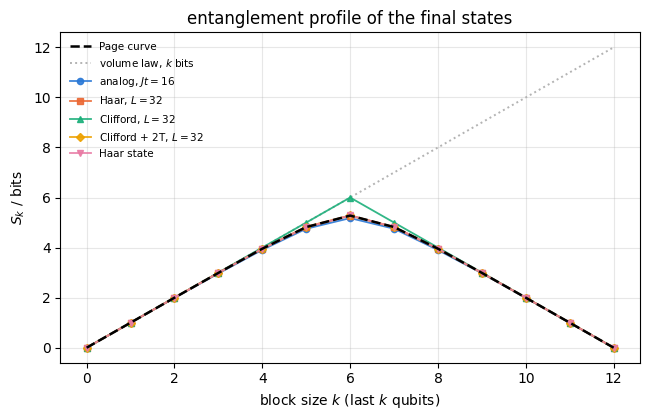

In [22]:
# ==============================================================================
# FIGURE: every scrambler builds the Page profile -- including the Clifford one
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.6, 4.3))
ks = np.arange(N + 1)
ax.plot(ks, page_profile, "k--", lw=1.8, label="Page curve", zorder=5)
ax.plot(ks, ks * 1.0, color="0.7", ls=":", lw=1.4, label="volume law, $k$ bits")
for j, (name, prof) in enumerate(profiles.items()):
    ax.plot(ks, prof, MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.3, alpha=0.9, label=name)
ax.set_xlabel("block size $k$ (last $k$ qubits)")
ax.set_ylabel("$S_k$ / bits")
ax.set_title("entanglement profile of the final states")
ax.legend(fontsize=7.5)
fig.tight_layout()
plt.show()

Every scrambler produces a volume law: the profile rises at close to one bit per qubit up to the half-way point
and bends over as Page's curve does. The Clifford profile is a staircase of integers; Page's value is an average
over non-integer entropies, so a single stabilizer state lies up to about one bit above or below it (this
realisation is maximally mixed up to $k=6$). The analog state lies about a tenth of a bit below Page near the
middle.

### 7.1 From the entropy of a block to its quantum Fisher information

The derivation of Eq. (5) already contains the mechanism. For a block close to maximally mixed,
$\rho_k=\mathbb{1}/d_A+\delta$, the entropy deficit and the quantum Fisher information are both quadratic in $\delta$.
Expanding $-\mathrm{Tr}\,\rho\log_2\rho$ to second order around $\mathbb{1}/d_A$,

$$k-S_k\approx\frac{d_A}{2\ln2}\,\mathrm{Tr}\,\delta^2,\qquad
F_k\approx d_A\sum_{m,n}\vert\delta_{mn}\vert^2\left(j_m-j_n\right)^2,$$

where the second form is the expression of Section 4.1 written in the eigenbasis of $J_A$ (eigenvalues $j_m$).
If the deviation $\delta$ has no preferred orientation relative to $J_A$, the factor $(j_m-j_n)^2$ averages to
$2\,\mathrm{Tr}J_A^2/d_A=k/2$, and

$$F_k\approx k\ln2\,\left(k-S_k\right)\qquad(k<N/2). \tag{9}$$

Two remarks. First, Eq. (9) applied to Page's deficit $k-S_k\approx d_A/(2d_B\ln2)$ reproduces Eq. (5), so the Haar
curve *is* the Page curve read through the quantum Fisher information. Second, both sides of Eq. (9) are quadratic
in $\delta$: neither quantity is more sensitive than the other near the maximally mixed state. A block of $k$
qubits locks exactly when its own entropy saturates. This is the precise sense in which the volume law is the
mechanism of locking. Eq. (9) is an estimate, not a bound; the next step measures how well it holds along the
dynamics.

### 7.2 Timing: the half-chain entropy against a block of three qubits

A natural but misleading comparison uses the half-chain entropy as the clock of scrambling. For each scrambler we
locate the time or depth $x_{95}$ at which the half-chain entropy first reaches $95\%$ of its Page value, and ask
how far a block of three qubits is from its Haar value at that moment, both in $r_3$ and in its own entropy
deficit $3-S_3$.

In [23]:
# ==============================================================================
# STEP 10: half-chain saturation time versus the locking of a block of three
# ==============================================================================
def first_crossing(x, y, level):
    """Smallest x at which the piecewise-linear interpolant of y(x) reaches `level` (nan if never)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    for i in range(1, len(x)):
        if y[i] >= level > y[i - 1]:
            f = (level - y[i - 1]) / (y[i] - y[i - 1])
            return x[i - 1] + f * (x[i] - x[i - 1])
    return np.nan


def interp_at(x, y, x0):
    """Piecewise-linear interpolation of y(x) at x0 (nan outside the range)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    return float(np.interp(x0, x, y)) if np.isfinite(x0) and x[0] <= x0 <= x[-1] else np.nan


K_PROBE = 3                                     # a quarter of the register
haar_r3 = haar_mean[N][K_PROBE]
page_def3 = K_PROBE - page_profile[K_PROBE]     # Page deficit of the block, bits

rows = [("analog (chaotic chain)", T_REC, ent_mean, ana_mean[:, K_PROBE], ana_S3.mean(0), "Jt")]
rows += [(name, DEPTHS, dig_ent[name], dig_mean[name][:, K_PROBE], dig_S3[name], "L") for name in DIGITAL]

print(f"locking of the block k = {K_PROBE}: Haar value r_3 = {haar_r3:.5f}, Page deficit 3 - S_3 = {page_def3:.4f} bits\n")
print(f"  {'scrambler':>22s} {'axis':>4} {'x95':>6} | {'at x95:':>7} {'r_3/Haar':>9} {'dS_3/Page':>10} | "
      f"{'at end:':>7} {'r_3/Haar':>9} {'dS_3/Page':>10} {'S_half/Page':>12}")
gap = {}
for name, xs, ent, r3, s3, axis in rows:
    x95 = first_crossing(xs, ent, 0.95 * S_PAGE)
    d3 = (K_PROBE - np.asarray(s3)) / page_def3          # entropy deficit of the SAME block, in Page units
    gap[name] = (x95, interp_at(xs, r3, x95) / haar_r3, interp_at(xs, d3, x95))
    print(f"  {name:>22s} {axis:>4} {x95:6.2f} | {'':7s} {gap[name][1]:9.1f} {gap[name][2]:10.1f} | "
          f"{'':7s} {r3[-1] / haar_r3:9.1f} {d3[-1]:10.1f} {ent[-1] / S_PAGE:12.3f}")
print(f"\n  x95 = time or depth at which the half-chain entropy first reaches 95% of the Page value;")
print(f"  'end' = Jt = {T_REC[-1]:g} for the analog chain, L = {DEPTHS[-1]} for the circuits.")

# --- CHECKPOINT: Eq. (9) along the evolution, for every block below the threshold -----------
# ratio F_k / (k ln2 (k - S_k)) on the final Haar-circuit states and on Haar-random states
print(f"\nEq. (9): F_k / (k ln2 (k - S_k)) on the final states, k = 2..{N // 2 - 1}:")
ratios9 = {}
for name, psi in final_states.items():
    if name.startswith("Clifford,"):
        continue                                          # stabilizer states: 0/0 when the block is maximally mixed
    c = locking_curve(psi)
    prof = entropy_profile(psi)
    ratios9[name] = np.array([c[k] / (k * np.log(2) * (k - prof[k])) for k in range(2, N // 2)])
    print(f"  {name.replace('$', ''):>26s}: " + "  ".join(f"{v:5.2f}" for v in ratios9[name]))
generic = np.concatenate([ratios9[nm] for nm in ratios9 if nm.startswith("Haar")])
assert 0.4 < generic.min() and generic.max() < 2.5          # Haar circuit and Haar state: Eq. (9) to about a factor 2
# along the Haar-circuit evolution (depth >= 8, where the block is close to maximally mixed): Eq. (9) keeps its
# ratio while the deficit shrinks by more than an order of magnitude; a QFI LINEAR in the deviation, F ~ sqrt(dS),
# would change its ratio by the square root of that factor -- the wrong control.
sel = [j for j, L in enumerate(DEPTHS) if L >= 8]
F3 = dig_raw["Haar"][:, sel, K_PROBE].mean(0)
dS3 = K_PROBE - dig_S3["Haar"][sel]
eq9, lin = F3 / (K_PROBE * np.log(2) * dS3), F3 / np.sqrt(dS3)
print(f"Haar circuit, depths {[DEPTHS[j] for j in sel]}: 3 - S_3 = {np.round(dS3, 4)}")
print(f"  Eq. (9) ratio            : {np.round(eq9, 2)}   (max/min = {eq9.max() / eq9.min():.2f})")
print(f"  control F_3/sqrt(3 - S_3): {np.round(lin, 3)}   (max/min = {lin.max() / lin.min():.2f})")
assert dS3.max() / dS3.min() > 10 and eq9.max() / eq9.min() < 2 and lin.max() / lin.min() > 2.5
# Haar-circuit timing: the same-block entropy deficit must lag exactly like r_3 does (the 'lag' is a block effect)
x95_haar, r3_lag, d3_lag = gap["Haar"]
print(f"Haar circuit at x95: r_3/Haar = {r3_lag:.1f}, (3 - S_3)/Page deficit = {d3_lag:.1f}  (ratio {r3_lag / d3_lag:.2f})")
assert r3_lag > 2 and d3_lag > 2 and 0.5 < r3_lag / d3_lag < 2

locking of the block k = 3: Haar value r_3 = 0.00194, Page deficit 3 - S_3 = 0.0111 bits

               scrambler axis    x95 | at x95:  r_3/Haar  dS_3/Page | at end:  r_3/Haar  dS_3/Page  S_half/Page
  analog (chaotic chain)   Jt   6.46 |               2.7        5.7 |               1.6        1.9        0.983
                    Haar    L  14.67 |               6.0        5.9 |               1.0        1.1        0.999
                Clifford    L  22.79 |              15.4       17.3 |               0.0        0.0        0.979
           Clifford + 2T    L  21.83 |               6.0        6.9 |               1.5        1.2        0.988

  x95 = time or depth at which the half-chain entropy first reaches 95% of the Page value;
  'end' = Jt = 16 for the analog chain, L = 32 for the circuits.

Eq. (9): F_k / (k ln2 (k - S_k)) on the final states, k = 2..5:
               analog, Jt=16:  0.61   0.29   0.60   0.73
                  Haar, L=32:  0.55   0.78   1.11   0.98
         Cliff

Read the two "at $x_{95}$" columns together. When the half-chain entropy first reaches $95\%$ of Page, a block of
three qubits still holds several times its Haar share of the phase information, which looks like a lag of the
metrological information behind the entanglement. The column next to it removes the lag: the entropy deficit of
the *same* block is several times its Page value at the same moment, by a comparable factor. The half-chain
entropy saturates first because it is a different quantity: a deficit of $5\%$ of $5.3$ bits is $0.26$ bits,
while the Page deficit of a block of three is $0.01$ bits, so the three-qubit block can be far from random in
relative terms while the half chain is already "saturated". The checkpoint confirms Eq. (9) within a factor of
two on the final Haar-circuit state and on a Haar-random state (single states of the other scramblers scatter
more, between about $0.3$ and $1.6$, at individual $k$); along the Haar-circuit evolution its ratio stays within
about $20\%$ while the deficit falls by a factor of twenty, which a quantum Fisher information linear in the
deviation would not survive. For the Haar circuit $r_3$ and the block entropy deficit lag the half-chain entropy by
comparable factors.

For the analog chain the block-three entropy deficit at $x_{95}$ is even larger, relative to Page, than $r_3$:
the ratio in Eq. (9) is below one along that evolution, because the deviation $\delta$ of a chain that conserves
its energy is not isotropic relative to $J_A$. At the end of the runs both columns are within a factor of about two
of their Haar values for every non-Clifford scrambler. For the Clifford circuits the two columns again agree at
$x_{95}$; at the end both vanish, because in these six realisations the block of three is exactly maximally
mixed (Section 6.2).

> **Physics insight.** "Is the system scrambled?" has no answer without saying *on which scale*. Locking of a block
> of $k$ qubits is governed by the entropy deficit of that block, Eq. (9), and the half-chain entropy is the
> wrong clock for small blocks. Compare like with like: a quantity of a block against the entropy of the same block.

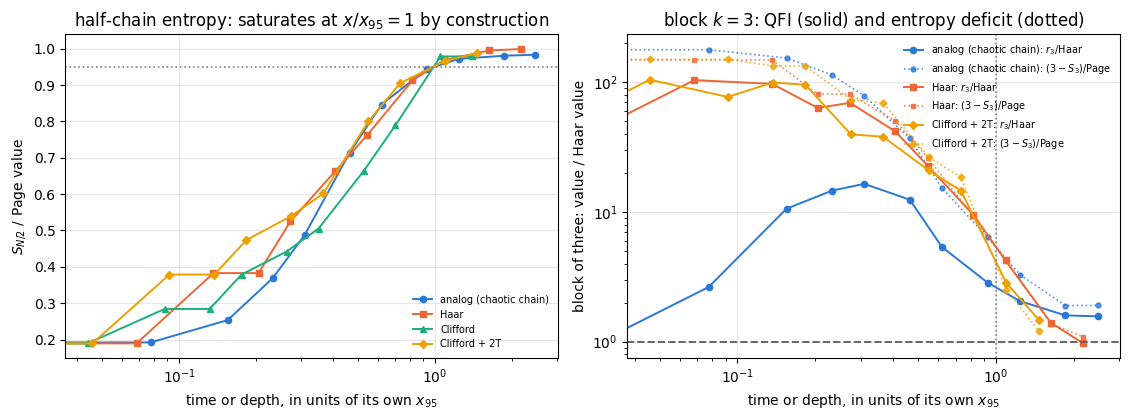

In [24]:
# ==============================================================================
# FIGURE: rescaled by the half-chain saturation scale -- r_3 and the block-3 entropy deficit move together
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))

for j, (name, xs, ent, r3, s3, axis) in enumerate(rows):
    xr = np.asarray(xs) / gap[name][0]
    axes[0].plot(xr, np.asarray(ent) / S_PAGE, MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4, label=name)
    if name != "Clifford":
        axes[1].plot(xr, np.asarray(r3) / haar_r3, MARKERS[j] + "-", color=PALETTE[j], ms=4.5, lw=1.4,
                     label=f"{name}: $r_3$/Haar")
        axes[1].plot(xr, (K_PROBE - np.asarray(s3)) / page_def3, MARKERS[j] + ":", color=PALETTE[j], ms=3.5,
                     lw=1.2, alpha=0.8, label=f"{name}: $(3-S_3)$/Page")
axes[0].axhline(0.95, color="0.5", ls=":", lw=1.2)
axes[0].set_ylabel("$S_{N/2}$ / Page value")
axes[0].set_title("half-chain entropy: saturates at $x/x_{95}=1$ by construction")
axes[1].axhline(1.0, color="0.4", ls="--", lw=1.4)
axes[1].axvline(1.0, color="0.5", ls=":", lw=1.2)
axes[1].set_yscale("log")
axes[1].set_ylabel("block of three: value / Haar value")
axes[1].set_title("block $k=3$: QFI (solid) and entropy deficit (dotted)")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("time or depth, in units of its own $x_{95}$")
axes[0].legend(fontsize=7, loc="lower right")
axes[1].legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()

Rescaling each scrambler by its own half-chain saturation scale collapses the entropy curves on the left, by
construction. On the right, each solid curve ($r_3$ relative to Haar) runs together with the dotted curve of the
same colour (the block-three entropy deficit relative to Page): the two quantities of the same block relax
together, as Eq. (9) says, and both are still well above one at $x/x_{95}=1$. The Clifford circuit is left out
of the right panel because both of its block quantities are zero in most realisations.

## 8. Cost

Three operations dominate the notebook.

* **One Trotter step** applies $2(N-1)$ bond gates and $2N$ field gates, each an einsum over one or two axes of
  a $2^N$ tensor: $O(N2^N)$ time, $O(2^N)$ memory. The whole evolution is one compiled program.
* **One brick-wall layer** applies $\lfloor N/2\rfloor$ two-qubit gates plus (for the Clifford sets) $N$
  single-qubit gates: the same $O(N2^N)$.
* **One point of the locking curve** costs a thin QR and a Hermitian eigendecomposition of dimension at most
  $2^{\min(k,N-k)+1}$, so $O(8^{\min(k,N-k)})$, peaking at $8^{N/2}=2^{1.5N}$ in the middle of the curve. Its
  memory, $O(2^N)$ for the reshaped state and $O(2^N)$ for the midpoint matrix, is no larger than the state's.

The curve's cost grows faster with $N$ than one evolution step, but an evolution has many steps: the analog run
to $Jt=16$ has $800$ of them. The cell below measures both at $N=12$ and estimates where they cross.

In [25]:
# ==============================================================================
# STEP 11: measured cost of the ingredients at N = 12
# ==============================================================================
key, sk = jax.random.split(key)
u_field_bench = field_propagators(sk, N, H_SCR)
_, c_step, t_step = timed(lambda p: analog_evolve(p, u_field_bench, CHUNK), psi_ghz)
key, sk = jax.random.split(key)
_, c_layer, t_layer = timed(jax.jit(lambda p: layer_haar(sk, p, 0)), psi_ghz)
_, c_curve, t_curve = timed(locking_curve, psi_analog_final)

print(f"{'operation':<44} {'compile':>10} {'run':>12}")
print(f"{f'{CHUNK} Trotter steps (one scan program)':<44} {c_step:9.3f}s {t_step * 1e3:10.2f} ms")
print(f"{'one Haar brick-wall layer':<44} {c_layer:9.3f}s {t_layer * 1e3:10.2f} ms")
phi_b = 0.5 * apply_collective(psi_analog_final, Z)
for k in (1, N // 2, N - 1):
    _, c_k, t_k = timed(_qfi_at_k(k), psi_analog_final, phi_b)
    print(f"{f'one locking-curve point, k = {k:2d}':<44} {c_k:9.3f}s {t_k * 1e3:10.2f} ms")
print(f"{'one full locking curve (k = 1..N)':<44} {'':>10} {t_curve * 1e3:10.2f} ms")

t_evol = t_step * n_chunks_final                           # the whole analog run to Jt = 16
ratio = t_evol / t_curve
n_cross = N + 2 * np.log2(ratio)                           # curve ~ 2^{1.5N}, evolution ~ 2^N: ratio falls by 2^{N/2}
print(f"\nanalog run to Jt = {T_FINAL:g} ({n_chunks_final * CHUNK} steps): {t_evol:.3f} s "
      f"= {ratio:.0f} locking curves")
print(f"rough crossover (ignoring the factor N of the evolution and all prefactors): N ~ {n_cross:.0f}")

operation                                       compile          run
25 Trotter steps (one scan program)              0.034s      31.15 ms
one Haar brick-wall layer                        1.209s       0.23 ms
one locking-curve point, k =  1                  0.000s       0.05 ms


one locking-curve point, k =  6                  0.002s       0.94 ms
one locking-curve point, k = 11                  0.000s       0.10 ms
one full locking curve (k = 1..N)                             9.81 ms

analog run to Jt = 16 (800 steps): 0.997 s = 102 locking curves
rough crossover (ignoring the factor N of the evolution and all prefactors): N ~ 25


At $N=12$ the evolution dominates: one run to $Jt=16$ costs as much as about a hundred locking curves (the exact
ratio depends on the machine and its load). The ratio falls by $2^{N/2}$ as $N$ grows, because the curve scales
as $2^{1.5N}$ and a step as $N2^N$, so the two costs cross only in the low-to-mid twenties, where both are
already demanding for a state-vector code. The size of this notebook is set by the number of realisations and
time points needed for reliable error bars, not by the diagnostic.

## 9. Key takeaways

* The **locking curve** $r_k=F_k/F_N$ measures what fraction of the quantum Fisher information of a globally
  imprinted phase survives in $k$ qubits. It depends on the pair (state, generator). With the phase imprinted
  after the scrambler (fixed generator $J_z$) the total itself collapses, from $N^2$ to about $N$; the curve shows
  where the remainder sits.
* For a **Haar-random state** the curve is derived in Eqs. (5)–(7): $r_k\approx k4^k/(2N2^N)$ below half the
  register, $r_{N/2}\approx0.198$ from the Marchenko-Pastur law, and $F_k\approx k$ (the standard quantum limit of
  the block) above it. At fixed $k/N$ the limit is $0$ below one half and $k/N$ above it.
* With the phase imprinted **before** the scrambler (rotated generator) $F_N=N^2$ is conserved and the curve is
  the sharp Hayden-Preskill step: $r_k\approx4^k/(2\cdot2^N)$ below the threshold, $1/2$ at it, and
  $r_k+r_{N-k}\approx1$.
* A **chaotic spin chain** locks a GHZ probe in two stages: the information first leaks out of the global
  coherence into finite blocks, and is then carried away again until the curve is close to the Haar one.
* The bare $XX+YY$ chain annihilates both $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, so the GHZ state is
  an exact **dark state** and never locks. The random transverse field is what couples the probe to the rest of
  the Hilbert space.
* **One layer of local gates destroys the Heisenberg scaling of the total**: $\mathbb{E}F_N^z=14N/15$ after one Haar
  layer, as derived in notebook 35. Later layers redistribute.
* **Clifford circuits reach the Haar locking curve on average**, as a 2-design must; every realisation is
  integer-valued and, for small blocks, usually zero. Magic shows up in the fluctuations, not in the mean.
* **The volume law is the mechanism, block by block**: $F_k\approx k\ln2\,(k-S_k)$, Eq. (9), with both sides
  quadratic in the deviation from the maximally mixed state. The half-chain entropy saturates before a block of
  three qubits locks, but the entropy of that same block lags by a comparable factor; the apparent lag is a
  comparison of different blocks.

## 10. Exercises

1. (&#9733;) **Finite-size corrections at the midpoint.** Measure $r_{N/2}$ for Haar-random states at
   $N=4,6,8,10,12,14$ with enough realisations for a standard error of $0.002$, and plot $r_{N/2}-0.198$ against
   $2^{-N/2}$. Estimate the size at which the finite-size correction falls below $1\%$ of Eq. (7). Explain, using
   Eqs. (5) and (6), why "half the qubits hold half the information" fails for this protocol.
2. (&#9733;) **A different generator.** Repeat Section 4.2 with $J_x$ and with the *staggered* generator
   $\sum_q(-1)^qZ_q/2$. Show from Eq. (5) that the leading-order curve depends on the generator only through
   $\mathrm{Tr}J_A^2$, and show that for these two generators the full Haar distribution of $F_k$ is the same as for
   $J_z$ (each is $J_z$ conjugated by a product of single-qubit unitaries). Confirm numerically.
3. (&#9733;&#9733;) **Another probe.** Replace the GHZ probe by $\vert+\rangle^{\otimes N}$ and by the GHZ state along
   $x$, $\left(\vert{+}\cdots{+}\rangle+\vert{-}\cdots{-}\rangle\right)/\sqrt2$. Evolve both under the chaotic chain
   ($h=1$) to $Jt=16$, and record $\max_aF_N^a$ and the locking curve for $J_z$. Compute $\langle H_{\text{scr}}\rangle$
   for each probe and compare it with $\mathrm{Tr}\,H_{\text{scr}}/2^N=0$. Which final curve is closer to the Haar
   one, and how does the conserved energy explain the difference?
4. (&#9733;&#9733;) **Disorder and the locking rate.** Extend the sweep of Section 5.5 into a rate measurement:
   for each $h\in\{0.25,0.5,1,2,4,8\}$, find the time *after its maximum* at which $r_3$ first falls below twice its
   Haar value, and plot that time against $h$. Is the dependence monotonic? At very large $h$ the field dominates
   the bonds; explain why that limit is also a bad scrambler (consider the single-site eigenstates of $h_qX_q$).
5. (&#9733;&#9733;) **Extend the code: fluctuations and magic.** For brick-wall circuits of depth $32$ with
   $n_T=0,1,2,4$ $T$ gates per layer, draw $48$ realisations each and compute (a) the stabilizer Rényi entropy
   $M_2$ (notebook 27) of each final state and (b) the relative standard deviation of $r_5$ between realisations.
   Plot (b) against the mean of (a). Does the spread fall monotonically with the magic, and does the *mean* $r_5$
   change at all?
6. (&#9733;&#9733;) **Where the staircase comes from.** For a Clifford final state, print the eigenvalues of
   $\rho_k$ for $k=1,\dots,N$ and confirm that each non-zero eigenvalue is $2^{-S_k}$ with multiplicity $2^{S_k}$. Use
   this and Eq. (1) to show that $F_k=4\left[\mathrm{Tr}(\rho_kJ_A^2)-2^{S_k}\,\mathrm{Tr}(\rho_kJ_A\rho_kJ_A)\right]$,
   then expand $J_A$ in Pauli operators to show that $F_k$ is an integer, as the checkpoints of Section 6 found.
7. (&#9733;&#9733;&#9733;) **The SLD without a full eigendecomposition.** The symmetric logarithmic derivative
   $L$ solves $\rho_kL+L\rho_k=2\,\partial_\theta\rho_k$, and $F_k=\mathrm{Tr}(\partial_\theta\rho_k\,L)$. Solve this linear
   equation by conjugate gradients, using only matrix products with $\rho_k$ (on the QR-compressed support for
   $k>N/2$). At $N=12$, $k=6$ for a Haar state, how many iterations give three significant digits? Then extend the
   timing of Step 11 to $N=8,\dots,18$ for both methods and locate the crossover with the evolution cost.
8. (&#9733;&#9733;&#9733;) **Physics: locking versus the light cone.** Section 5.4 found that the peak of
   $r_k(t)$ moves to later times as $k$ grows. Record the curve every $J\Delta t=0.1$ up to $Jt=4$, extract the peak
   time $t^\ast(k)$ and test whether it is linear in $k$. Compare the slope with the front velocity of the
   connected correlations $\langle Z_0Z_r\rangle-\langle Z_0\rangle\langle Z_r\rangle$ of the same chain, started from $\vert0\cdots0\rangle$ with one
   spin flipped and measured by the threshold method of notebook 15, and with the maximal group velocity $4J$ of
   the bare chain ($h=0$, free fermions with hopping $2J$). Should the two velocities agree?

## 11. References

* D. N. Page, *Average entropy of a subsystem*, Phys. Rev. Lett. **71**, 1291 (1993) — the Page curve used as
  the entanglement reference throughout.
* P. Hayden and J. Preskill, *Black holes as mirrors: quantum information in random subsystems*,
  J. High Energy Phys. **2007**(09), 120 (2007) — the half-system threshold for recovering information from a
  scrambled system (Section 4.3).
* D. A. Roberts and B. Yoshida, *Chaos and complexity by design*, J. High Energy Phys. **2017**(04), 121 (2017)
  — chaos and unitary designs, Clifford against Haar averages, and the role of the gate set (Section 6.2).
* A. Nahum, J. Ruhman, S. Vijay and J. Haah, *Quantum entanglement growth under random unitary dynamics*,
  Phys. Rev. X **7**, 031016 (2017) — entanglement growth and saturation in brick-wall circuits.
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the quantum Fisher information and the symmetric logarithmic
  derivative.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical
  states of atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the metrological context.
* G. Tóth and I. Apellaniz, *Quantum metrology from a quantum information science perspective*,
  J. Phys. A: Math. Theor. **47**, 424006 (2014) — quantum Fisher information of mixed and reduced states.
* D. Gottesman, *The Heisenberg representation of quantum computers*, in *Group22: Proceedings of the XXII
  International Colloquium on Group Theoretical Methods in Physics*, eds. S. P. Corney, R. Delbourgo and P. D.
  Jarvis (International Press, Cambridge MA, 1999), pp. 32–43; arXiv:quant-ph/9807006 — the Gottesman-Knill
  theorem behind the Clifford scrambler.
* L. Leone, S. F. E. Oliviero and A. Hamma, *Stabilizer Rényi entropy*, Phys. Rev. Lett. **128**, 050402 (2022)
  — the magic measure of Exercise 5.
* F. Mezzadri, *How to generate random matrices from the classical compact groups*, Notices Am. Math. Soc.
  **54**(5), 592–604 (2007) — the QR recipe behind `haar_unitary`.
* V. A. Marchenko and L. A. Pastur, *Distribution of eigenvalues for some sets of random matrices*,
  Mat. Sb. **72(114)**, 507–536 (1967); English translation Math. USSR-Sb. **1**, 457 (1967) — the eigenvalue law
  behind Eq. (7).
* M. Suzuki, *Fractal decomposition of exponential operators with applications to many-body theories and Monte
  Carlo simulations*, Phys. Lett. A **146**, 319 (1990) — the recursive construction of higher-order product formulas
  from the symmetric second-order splitting, which is the one used by the Trotter step.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific
  Computing*, 3rd ed., Cambridge University Press (2007) — Chapter 11 for the symmetric eigenproblem and
  Chapter 2 for the QR factorisation used to compress the active subspace.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/